In [177]:
import requests
import json
import pandas as pd
from IPython.display import display
import requests
import pandas as pd
import time
import numpy as np
import pandas as pd
import numpy as np
import re

In [179]:
base_url = 'https://api.fda.gov/device/event.json'

# Define parameters
params = {
    'search': '',
    'limit': '100',
    'skip': '0'
}

response = requests.get(base_url, params=params)

# Check request
if response.status_code == 200:
    data = response.json()
    # Access the results
    events = data.get('results', [])
    print(f'Number of events retrieved: {len(events)}')

    if len(events) > 0:
        df = pd.json_normalize(events)
        display(df.head())
    else:
        print('No events found in the data.')
else:
    print(f'Error: {response.status_code}')

Number of events retrieved: 100


,manufacturer_contact_zip_ext,manufacturer_g1_address_2,event_location,report_to_fda,manufacturer_contact_t_name,manufacturer_contact_state,manufacturer_link_flag,manufacturer_contact_address_2,manufacturer_g1_city,manufacturer_contact_address_1,manufacturer_contact_pcity,event_type,report_number,type_of_report,product_problem_flag,date_received,manufacturer_address_2,pma_pmn_number,date_of_event,reprocessed_and_reused_flag,manufacturer_address_1,report_date,exemption_number,manufacturer_contact_zip_code,reporter_occupation_code,manufacturer_contact_plocal,noe_summarized,manufacturer_contact_l_name,source_type,distributor_zip_code_ext,manufacturer_g1_postal_code,date_facility_aware,manufacturer_g1_state,reporter_country_code,manufacturer_contact_area_code,date_added,manufacturer_contact_f_name,previous_use_code,device,manufacturer_zip_code,suppl_dates_mfr_received,manufacturer_contact_country,date_changed,health_professional,summary_report_flag,manufacturer_g1_zip_code_ext,manufacturer_contact_extension,manufacturer_city,manufacturer_contact_phone_number,patient,distributor_city,date_report,initial_report_to_fda,distributor_state,event_key,manufacturer_g1_country,manufacturer_contact_city,mdr_report_key,removal_correction_number,number_devices_in_event,date_report_to_fda,manufacturer_name,report_source_code,remedial_action,manufacturer_g1_zip_code,report_to_manufacturer,manufacturer_zip_code_ext,manufacturer_g1_name,adverse_event_flag,distributor_address_1,manufacturer_state,distributor_address_2,manufacturer_postal_code,single_use_flag,manufacturer_country,mdr_text,number_patients_in_event,distributor_name,manufacturer_g1_address_1,distributor_zip_code,manufacturer_contact_postal_code,manufacturer_contact_exchange,manufacturer_contact_pcountry,suppl_dates_fda_received,date_report_to_manufacturer,device_date_of_manufacturer,product_problems,date_manufacturer_received
0,,,HOSPITAL,Y,,,N,,,,,Injury,10,[Initial submission],N,19920310,,,19920220,,,19920221,,,,,1,,[],,,19920220,,,,19920319,,,"[{'device_event_key': '8', 'implant_flag': 'N'...",,,,20200623,,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,19920221,,,,,,10,,,19920221,,User Facility report,[],,,,,Y,,,,,,,"[{'mdr_text_key': '3', 'text_type_code': 'Desc...",,,,,,,,,NaN,NaN,NaN,NaN
1,,,OTHER,Y,,,N,,,,,Injury,2243621-1992-00036,[Initial submission],N,19920722,,,19920629,,,19920708,,,UNKNOWN,,1,,[],,,19920629,,US,,19920803,,,"[{'device_event_key': '956', 'implant_flag': '...",,,,19920803,U,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,19920708,Unknown,,,,,1000,,,19920708,,Distributor report,[],,,,,Y,,,,,,,"[{'mdr_text_key': '614', 'text_type_code': 'De...",,,,,,,,,19920708,NaN,NaN,NaN
2,,,INVALID DATA,N,,,N,,,,,No answer provided,10000,[Initial submission],*,19940805,,,NaN,,,19940728,,,,,1,,[],,,NaN,,,,19950306,,,"[{'device_event_key': '9652', 'implant_flag': ...",,,,19950306,,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,19940728,,,,,,10000,,,NaN,,User Facility report,[],,,,,*,,,,,,,"[{'mdr_text_key': '5377', 'text_type_code': 'D...",,,,,,,,,NaN,NaN,NaN,NaN
3,,,HOSPITAL,N,,,N,,,,,Injury,100000,[Initial submission],Y,19970619,,,19970428,,,19970509,,,PHYSICIAN,,1,,[],,,19970428,,US,,19970625,,,"[{'device_event_key': '98520', 'implant_flag':...",,,,19970625,Y,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,19970429,No,,,,,100000,,,NaN,,User Facility report,[],,,,,N,,,,,,,"[{'mdr_text_key': '21392769', 'text_type_code'...",,,,,,,,,NaN,NaN,NaN,NaN
4,,,,,,,Y,,,,,Malfunction,2919069-2008-00381,"[Initial submission, Followup]",Y,20080220,,K051215,20071216,N,,NaN,,,,,1,,"[Consumer, Health Professional]",,,NaN,,,,20091228,,,"[{'device_event_key': '', 'implant_flag': '', ...",,*,,20221102,,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,20080122,,,,,,1000000,2919069-8/6/07-004-C,,NaN,,Manufacturer report,[Replace],,,,,N,,,,,,,"[{'mdr_text_key': '788224', 'text_type_code': ...",,,,,,,,12/28/2009,NaN,NaN,NaN,NaN


In [311]:
base_url = 'https://api.fda.gov/device/event.json'

all_events = []

total_records = 10000
batch_size = 100

#number of batches needed
num_batches = total_records // batch_size

for i in range(num_batches):
    # Calculate the 'skip' value
    skip = i * batch_size

    # Define parameters
    params = {
        'search': '',            # Empty search retrieves all records
        'limit': str(batch_size),
        'skip': str(skip)
    }

    response = requests.get(base_url, params=params)

    if response.status_code == 200:
        data = response.json()
        events = data.get('results', [])
        all_events.extend(events)
        print(f"Retrieved {len(events)} records. Total records so far: {len(all_events)}")
    else:
        print(f'Error: {response.status_code}')
        break

    #To avoid hitting rate limits
    time.sleep(0.2)

df = pd.json_normalize(all_events)

print(f'\nTotal records retrieved: {len(df)}')

df.head()


Retrieved 100 records. Total records so far: 100
Retrieved 100 records. Total records so far: 200
Retrieved 100 records. Total records so far: 300
Retrieved 100 records. Total records so far: 400
Retrieved 100 records. Total records so far: 500
Retrieved 100 records. Total records so far: 600
Retrieved 100 records. Total records so far: 700
Retrieved 100 records. Total records so far: 800
Retrieved 100 records. Total records so far: 900
Retrieved 100 records. Total records so far: 1000
Retrieved 100 records. Total records so far: 1100
Retrieved 100 records. Total records so far: 1200
Retrieved 100 records. Total records so far: 1300
Retrieved 100 records. Total records so far: 1400
Retrieved 100 records. Total records so far: 1500
Retrieved 100 records. Total records so far: 1600
Retrieved 100 records. Total records so far: 1700
Retrieved 100 records. Total records so far: 1800
Retrieved 100 records. Total records so far: 1900
Retrieved 100 records. Total records so far: 2000
Retrieved

,manufacturer_contact_zip_ext,manufacturer_g1_address_2,event_location,report_to_fda,manufacturer_contact_t_name,manufacturer_contact_state,manufacturer_link_flag,manufacturer_contact_address_2,manufacturer_g1_city,manufacturer_contact_address_1,manufacturer_contact_pcity,event_type,report_number,type_of_report,product_problem_flag,date_received,manufacturer_address_2,pma_pmn_number,date_of_event,reprocessed_and_reused_flag,manufacturer_address_1,report_date,exemption_number,manufacturer_contact_zip_code,reporter_occupation_code,manufacturer_contact_plocal,noe_summarized,manufacturer_contact_l_name,source_type,distributor_zip_code_ext,manufacturer_g1_postal_code,date_facility_aware,manufacturer_g1_state,reporter_country_code,manufacturer_contact_area_code,date_added,manufacturer_contact_f_name,previous_use_code,device,manufacturer_zip_code,suppl_dates_mfr_received,manufacturer_contact_country,date_changed,health_professional,summary_report_flag,manufacturer_g1_zip_code_ext,manufacturer_contact_extension,manufacturer_city,manufacturer_contact_phone_number,patient,distributor_city,date_report,initial_report_to_fda,distributor_state,event_key,manufacturer_g1_country,manufacturer_contact_city,mdr_report_key,removal_correction_number,number_devices_in_event,date_report_to_fda,manufacturer_name,report_source_code,remedial_action,manufacturer_g1_zip_code,report_to_manufacturer,manufacturer_zip_code_ext,manufacturer_g1_name,adverse_event_flag,distributor_address_1,manufacturer_state,distributor_address_2,manufacturer_postal_code,single_use_flag,manufacturer_country,mdr_text,number_patients_in_event,distributor_name,manufacturer_g1_address_1,distributor_zip_code,manufacturer_contact_postal_code,manufacturer_contact_exchange,manufacturer_contact_pcountry,suppl_dates_fda_received,date_report_to_manufacturer,device_date_of_manufacturer,product_problems,date_manufacturer_received
0,,,HOSPITAL,Y,,,N,,,,,Injury,10,[Initial submission],N,19920310,,,19920220,,,19920221,,,,,1,,[],,,19920220,,,,19920319,,,"[{'device_event_key': '8', 'implant_flag': 'N'...",,,,20200623,,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,19920221,,,,,,10,,,19920221,,User Facility report,[],,,,,Y,,,,,,,"[{'mdr_text_key': '3', 'text_type_code': 'Desc...",,,,,,,,,NaN,NaN,NaN,NaN
1,,,OTHER,Y,,,N,,,,,Injury,2243621-1992-00036,[Initial submission],N,19920722,,,19920629,,,19920708,,,UNKNOWN,,1,,[],,,19920629,,US,,19920803,,,"[{'device_event_key': '956', 'implant_flag': '...",,,,19920803,U,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,19920708,Unknown,,,,,1000,,,19920708,,Distributor report,[],,,,,Y,,,,,,,"[{'mdr_text_key': '614', 'text_type_code': 'De...",,,,,,,,,19920708,NaN,NaN,NaN
2,,,INVALID DATA,N,,,N,,,,,No answer provided,10000,[Initial submission],*,19940805,,,NaN,,,19940728,,,,,1,,[],,,NaN,,,,19950306,,,"[{'device_event_key': '9652', 'implant_flag': ...",,,,19950306,,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,19940728,,,,,,10000,,,NaN,,User Facility report,[],,,,,*,,,,,,,"[{'mdr_text_key': '5377', 'text_type_code': 'D...",,,,,,,,,NaN,NaN,NaN,NaN
3,,,HOSPITAL,N,,,N,,,,,Injury,100000,[Initial submission],Y,19970619,,,19970428,,,19970509,,,PHYSICIAN,,1,,[],,,19970428,,US,,19970625,,,"[{'device_event_key': '98520', 'implant_flag':...",,,,19970625,Y,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,19970429,No,,,,,100000,,,NaN,,User Facility report,[],,,,,N,,,,,,,"[{'mdr_text_key': '21392769', 'text_type_code'...",,,,,,,,,NaN,NaN,NaN,NaN
4,,,,,,,Y,,,,,Malfunction,2919069-2008-00381,"[Initial submission, Followup]",Y,20080220,,K051215,20071216,N,,NaN,,,,,1,,"[Consumer, Health Professional]",,,NaN,,,,20091228,,,"[{'device_event_key': '', 'implant_flag': '', ...",,*,,20221102,,N,,,,,"[{'patient_sequence_number': '1', 'date_receiv...",,20080122,,,,,,1000000,2919069-8/6/07-004-C,,NaN,,Manufacturer report,[Replace],,,,,N,,,,,,,"[{'mdr_text_key': '788224', 'text_type_code': ...",,,,,,,,12/28/2009,NaN,NaN,NaN,NaN


In [181]:
# Checking for empty strings in a column
(df['manufacturer_contact_zip_ext'] == '').sum()


np.int64(8053)

In [182]:
missing_values = ['', ' ', 'N/A', 'NA', 'n/a', 'na', 'NULL', 'null', 'NaN', 'NaT', 'nan', 'Unknown', 'unknown', 'NONE', 'none']



In [183]:
# Replacing Placeholders with NaN
df.replace(missing_values, np.nan, inplace=True)


/tmp/ipython-input-160115633.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(missing_values, np.nan, inplace=True)


In [184]:
missing_counts = df.isnull().sum()
print(missing_counts)

manufacturer_contact_zip_ext          8053
manufacturer_g1_address_2             9199
event_location                        1297
report_to_fda                         1292
manufacturer_contact_t_name           7974
manufacturer_contact_state            4755
manufacturer_link_flag                   0
manufacturer_contact_address_2        9656
manufacturer_g1_city                  5199
manufacturer_contact_address_1        3897
manufacturer_contact_pcity            3287
event_type                               0
report_number                            0
type_of_report                           0
product_problem_flag                    63
date_received                            0
manufacturer_address_2               10000
pma_pmn_number                        3100
date_of_event                         1563
reprocessed_and_reused_flag            123
manufacturer_address_1               10000
report_date                           9532
exemption_number                     10000
manufacture

In [312]:
# Calculate Missing Data Percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(missing_percent.sort_values(ascending=False))

date_report_to_manufacturer          97.53
date_report_to_fda                   97.27
report_date                          95.32
date_facility_aware                  94.43
device_date_of_manufacturer          49.21
date_of_event                        15.63
product_problems                      9.82
date_manufacturer_received            8.90
date_report                           5.29
manufacturer_contact_address_2        0.00
manufacturer_g1_city                  0.00
manufacturer_contact_address_1        0.00
report_number                         0.00
type_of_report                        0.00
manufacturer_contact_pcity            0.00
event_type                            0.00
date_received                         0.00
manufacturer_link_flag                0.00
manufacturer_contact_zip_ext          0.00
manufacturer_g1_address_2             0.00
manufacturer_contact_t_name           0.00
manufacturer_contact_state            0.00
event_location                        0.00
report_to_f

In [188]:
# Lists to store columns with nested data
nested_columns = []

for col in df.columns:
    # Get the first non-null value in the column
    non_null_series = df[col].dropna()

    if not non_null_series.empty:
        first_entry = non_null_series.iloc[0]
        if isinstance(first_entry, (list, dict)):
            nested_columns.append(col)
            print(f"Column: {col}, Data Type: {type(first_entry)}")
    else:
        print(f"Column: {col} is empty after dropping NaNs.")


Column: type_of_report, Data Type: <class 'list'>
Column: manufacturer_address_2 is empty after dropping NaNs.
Column: manufacturer_address_1 is empty after dropping NaNs.
Column: exemption_number is empty after dropping NaNs.
Column: source_type, Data Type: <class 'list'>
Column: distributor_zip_code_ext is empty after dropping NaNs.
Column: device, Data Type: <class 'list'>
Column: manufacturer_zip_code is empty after dropping NaNs.
Column: manufacturer_city is empty after dropping NaNs.
Column: patient, Data Type: <class 'list'>
Column: distributor_city is empty after dropping NaNs.
Column: distributor_state is empty after dropping NaNs.
Column: event_key is empty after dropping NaNs.
Column: number_devices_in_event is empty after dropping NaNs.
Column: manufacturer_name is empty after dropping NaNs.
Column: remedial_action, Data Type: <class 'list'>
Column: report_to_manufacturer is empty after dropping NaNs.
Column: manufacturer_zip_code_ext is empty after dropping NaNs.
Column: d

In [189]:
print("\nColumns with nested data:")
print(nested_columns)


Columns with nested data:
['type_of_report', 'source_type', 'device', 'patient', 'remedial_action', 'mdr_text', 'product_problems']


In [191]:
# Checking the Contents of the Lists/ Types of Elements inside the lists

# Function to check the type of elements inside the lists
def check_list_contents(column_name):
    non_null_series = df[column_name].dropna()
    if non_null_series.empty:
        print(f"Column '{column_name}' is empty after dropping NaNs.")
        return
    first_entry = non_null_series.iloc[0]
    # Ensure the entry is a list
    if isinstance(first_entry, list):
        if not first_entry:
            print(f"Column '{column_name}' contains empty lists.")
            return
        first_element = first_entry[0]
        print(f"Column '{column_name}' contains lists of type: {type(first_element)}")
        # Optionally, print the first few entries
        print(f"Sample data from '{column_name}':")
        print(first_entry)
    else:
        print(f"Column '{column_name}' entries are not lists.")

# Check each nested column
for col in nested_columns:
    check_list_contents(col)

Column 'type_of_report' contains lists of type: <class 'str'>
Sample data from 'type_of_report':
['Initial submission']
Column 'source_type' contains lists of type: <class 'str'>
Sample data from 'source_type':
['']
Column 'device' contains lists of type: <class 'dict'>
Sample data from 'device':
[{'device_event_key': '8', 'implant_flag': 'N', 'date_removed_flag': '', 'device_sequence_number': '1', 'date_received': '19920310', 'brand_name': 'N/A', 'generic_name': 'MANUAL HOSPITAL BED', 'manufacturer_d_name': 'SCI-O-TECH/GOODMAN', 'manufacturer_d_address_1': '', 'manufacturer_d_address_2': '', 'manufacturer_d_city': '', 'manufacturer_d_state': '', 'manufacturer_d_zip_code': '', 'manufacturer_d_zip_code_ext': '', 'manufacturer_d_country': '', 'manufacturer_d_postal_code': '', 'model_number': '720', 'catalog_number': 'N/A', 'lot_number': 'N/A', 'other_id_number': 'N/A', 'device_operator': 'OTHER CAREGIVERS', 'device_availability': 'Yes', 'device_report_product_code': 'FNJ', 'device_age_te

In [192]:
# Checking if a Unique Identifier Exists in the dataframe

if df['report_number'].is_unique:
    df['unique_id'] = df['report_number']
else:
    # create a new unique ID
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'unique_id'}, inplace=True)
is_unique = df['report_number'].is_unique
print(f"'report_number' is unique: {is_unique}")
df['unique_id'] = df['report_number']

'report_number' is unique: True


In [193]:
df.head()

,manufacturer_contact_zip_ext,manufacturer_g1_address_2,event_location,report_to_fda,manufacturer_contact_t_name,manufacturer_contact_state,manufacturer_link_flag,manufacturer_contact_address_2,manufacturer_g1_city,manufacturer_contact_address_1,manufacturer_contact_pcity,event_type,report_number,type_of_report,product_problem_flag,date_received,manufacturer_address_2,pma_pmn_number,date_of_event,reprocessed_and_reused_flag,manufacturer_address_1,report_date,exemption_number,manufacturer_contact_zip_code,reporter_occupation_code,manufacturer_contact_plocal,noe_summarized,manufacturer_contact_l_name,source_type,distributor_zip_code_ext,manufacturer_g1_postal_code,date_facility_aware,manufacturer_g1_state,reporter_country_code,manufacturer_contact_area_code,date_added,manufacturer_contact_f_name,previous_use_code,device,manufacturer_zip_code,suppl_dates_mfr_received,manufacturer_contact_country,date_changed,health_professional,summary_report_flag,manufacturer_g1_zip_code_ext,manufacturer_contact_extension,manufacturer_city,manufacturer_contact_phone_number,patient,distributor_city,date_report,initial_report_to_fda,distributor_state,event_key,manufacturer_g1_country,manufacturer_contact_city,mdr_report_key,removal_correction_number,number_devices_in_event,date_report_to_fda,manufacturer_name,report_source_code,remedial_action,manufacturer_g1_zip_code,report_to_manufacturer,manufacturer_zip_code_ext,manufacturer_g1_name,adverse_event_flag,distributor_address_1,manufacturer_state,distributor_address_2,manufacturer_postal_code,single_use_flag,manufacturer_country,mdr_text,number_patients_in_event,distributor_name,manufacturer_g1_address_1,distributor_zip_code,manufacturer_contact_postal_code,manufacturer_contact_exchange,manufacturer_contact_pcountry,suppl_dates_fda_received,date_report_to_manufacturer,device_date_of_manufacturer,product_problems,date_manufacturer_received,unique_id
0,NaN,NaN,HOSPITAL,Y,NaN,NaN,N,NaN,NaN,NaN,NaN,Injury,10,[Initial submission],N,19920310,NaN,NaN,19920220,NaN,NaN,19920221,NaN,NaN,NaN,NaN,1,NaN,[],NaN,NaN,19920220,NaN,NaN,NaN,19920319,NaN,NaN,"[{'device_event_key': '8', 'implant_flag': 'N'...",NaN,NaN,NaN,20200623,NaN,N,NaN,NaN,NaN,NaN,"[{'patient_sequence_number': '1', 'date_receiv...",NaN,19920221,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,19920221,NaN,User Facility report,[],NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,"[{'mdr_text_key': '3', 'text_type_code': 'Desc...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,NaN,NaN,OTHER,Y,NaN,NaN,N,NaN,NaN,NaN,NaN,Injury,2243621-1992-00036,[Initial submission],N,19920722,NaN,NaN,19920629,NaN,NaN,19920708,NaN,NaN,UNKNOWN,NaN,1,NaN,[],NaN,NaN,19920629,NaN,US,NaN,19920803,NaN,NaN,"[{'device_event_key': '956', 'implant_flag': '...",NaN,NaN,NaN,19920803,U,N,NaN,NaN,NaN,NaN,"[{'patient_sequence_number': '1', 'date_receiv...",NaN,19920708,NaN,NaN,NaN,NaN,NaN,1000,NaN,NaN,19920708,NaN,Distributor report,[],NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,"[{'mdr_text_key': '614', 'text_type_code': 'De...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19920708,NaN,NaN,NaN,2243621-1992-00036
2,NaN,NaN,INVALID DATA,N,NaN,NaN,N,NaN,NaN,NaN,NaN,No answer provided,10000,[Initial submission],*,19940805,NaN,NaN,NaN,NaN,NaN,19940728,NaN,NaN,NaN,NaN,1,NaN,[],NaN,NaN,NaN,NaN,NaN,NaN,19950306,NaN,NaN,"[{'device_event_key': '9652', 'implant_flag': ...",NaN,NaN,NaN,19950306,NaN,N,NaN,NaN,NaN,NaN,"[{'patient_sequence_number': '1', 'date_receiv...",NaN,19940728,NaN,NaN,NaN,NaN,NaN,10000,NaN,NaN,NaN,NaN,User Facility report,[],NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,"[{'mdr_text_key': '5377', 'text_type_code': 'D...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000
3,NaN,NaN,HOSPITAL,N,NaN,NaN,N,NaN,NaN,NaN,NaN,Injury,100000,[Initial submission],Y,19970619,NaN,NaN,19970428,NaN,NaN,19970509,NaN,NaN,PHYSICIAN,NaN,1,NaN,[],NaN,NaN,19970428,NaN,US,NaN,19970625,NaN,NaN,"[{'device_event_key': '98520', 'implant_flag':...",NaN,NaN,NaN,19970625,Y,N,NaN,NaN,NaN,NaN,"[{'patient_sequence_number': '1', 'date_receiv.

In [194]:
# Exploding the Lists of Strings While Keeping the Identifier
# Exploding these 4 columns will put the elements in the lists in a seperate row.

#Columns to Explode:'product_problems', 'type_of_report', 'source_type', 'remedial_action'

# Exploding 'product_problems' while keeping 'unique_id'
df_pp = df[['unique_id', 'product_problems']].explode('product_problems')
df_pp.reset_index(drop=True, inplace=True)

In [195]:
df_tor = df[['unique_id', 'type_of_report']].explode('type_of_report')
df_tor.reset_index(drop=True, inplace=True)
df_st = df[['unique_id', 'source_type']].explode('source_type')
df_st.reset_index(drop=True, inplace=True)
df_ra = df[['unique_id', 'remedial_action']].explode('remedial_action')
df_ra.reset_index(drop=True, inplace=True)

In [196]:
df['remedial_action'].value_counts()

,count
remedial_action,
[],9046
[Recall],617
[Other],212
[Notification],82
[Inspection],24
[Replace],15
[Repair],2
[Relabeling],1
[Modification/Adjustment],1


In [197]:
df_device = df[['unique_id', 'device']].copy()
df_device_exploded = df_device.explode('device')

In [199]:
print("Data types in 'device' column before exploding:")
print(df_device['device'].apply(type).value_counts())

# After exploding
print("\nData types in 'device' column after exploding:")
print(df_device_exploded['device'].apply(type).value_counts())

Data types in 'device' column before exploding:
device
<class 'list'>    10000
Name: count, dtype: int64

Data types in 'device' column after exploding:
device
<class 'dict'>    10018
Name: count, dtype: int64


In [200]:
df_device_exploded.reset_index(drop=True, inplace=True)
print("\nStep 3: After resetting index, df_device_exploded.head()")
print(df_device_exploded.head())


Step 3: After resetting index, df_device_exploded.head()
            unique_id                                             device
0                  10  {'device_event_key': '8', 'implant_flag': 'N',...
1  2243621-1992-00036  {'device_event_key': '956', 'implant_flag': 'N...
2               10000  {'device_event_key': '9652', 'implant_flag': '...
3              100000  {'device_event_key': '98520', 'implant_flag': ...
4  2919069-2008-00381  {'device_event_key': '', 'implant_flag': '', '...


In [201]:
device_normalized = pd.json_normalize(df_device_exploded['device'])
print("\nStep 4: device_normalized.head()")
print(device_normalized.head(3))


Step 4: device_normalized.head()
  device_event_key implant_flag date_removed_flag device_sequence_number  \
0                8            N                                        1   
1              956            N                                        1   
2             9652            *                                        1   

  date_received        brand_name         generic_name  \
0      19920310               N/A  MANUAL HOSPITAL BED   
1      19920722     SAME AS ABOVE             DIALYZER   
2      19940805  TRANSFER CHAMBER                        

            manufacturer_d_name manufacturer_d_address_1  \
0            SCI-O-TECH/GOODMAN                            
1  GAMBRO PLATE LUNDIA DIALYZER                            
2                     SIM/INTEC                            

  manufacturer_d_address_2 manufacturer_d_city manufacturer_d_state  \
0                                                                     
1                                            

In [202]:
# Prefix the column names
device_normalized.columns = [f"device.{col}" for col in device_normalized.columns]
print(device_normalized.columns)

Index(['device.device_event_key', 'device.implant_flag',
       'device.date_removed_flag', 'device.device_sequence_number',
       'device.date_received', 'device.brand_name', 'device.generic_name',
       'device.manufacturer_d_name', 'device.manufacturer_d_address_1',
       'device.manufacturer_d_address_2', 'device.manufacturer_d_city',
       'device.manufacturer_d_state', 'device.manufacturer_d_zip_code',
       'device.manufacturer_d_zip_code_ext', 'device.manufacturer_d_country',
       'device.manufacturer_d_postal_code', 'device.model_number',
       'device.catalog_number', 'device.lot_number', 'device.other_id_number',
       'device.device_operator', 'device.device_availability',
       'device.device_report_product_code', 'device.device_age_text',
       'device.device_evaluated_by_manufacturer',
       'device.baseline_510_k__flag', 'device.baseline_510_k__number',
       'device.baseline_510_k__exempt_flag', 'device.openfda.device_name',
       'device.openfda.medical_

In [203]:
df_device_flattened = pd.concat([df_device_exploded[['unique_id']], device_normalized], axis=1)
print(df_device_flattened.head(2))

            unique_id device.device_event_key device.implant_flag  \
0                  10                       8                   N   
1  2243621-1992-00036                     956                   N   

  device.date_removed_flag device.device_sequence_number device.date_received  \
0                                                      1             19920310   
1                                                      1             19920722   

  device.brand_name  device.generic_name    device.manufacturer_d_name  \
0               N/A  MANUAL HOSPITAL BED            SCI-O-TECH/GOODMAN   
1     SAME AS ABOVE             DIALYZER  GAMBRO PLATE LUNDIA DIALYZER   

  device.manufacturer_d_address_1 device.manufacturer_d_address_2  \
0                                                                   
1                                                                   

  device.manufacturer_d_city device.manufacturer_d_state  \
0                                                        

In [204]:
df_patient = df[['unique_id', 'patient']].copy()
df_patient_exploded = df_patient.explode('patient')

In [205]:
df_patient_exploded.reset_index(drop=True, inplace=True)

In [206]:
patient_normalized = pd.json_normalize(df_patient_exploded['patient'])
print(patient_normalized.head(3))

  patient_sequence_number date_received sequence_number_treatment  \
0                       1      19920310                        []   
1                       1      19920722                        []   
2                       1      19940805                        []   

   sequence_number_outcome patient_age patient_sex patient_weight  \
0  [Required Intervention]       92 YR                              
1                  [Other]                                          
2           [Invalid Data]         UNK                              

  patient_ethnicity patient_race patient_problems  
0                                             NaN  
1                                             NaN  
2                                             NaN  


In [207]:
patient_normalized.columns = [f"patient.{col}" for col in patient_normalized.columns]
print(patient_normalized.columns)

Index(['patient.patient_sequence_number', 'patient.date_received',
       'patient.sequence_number_treatment', 'patient.sequence_number_outcome',
       'patient.patient_age', 'patient.patient_sex', 'patient.patient_weight',
       'patient.patient_ethnicity', 'patient.patient_race',
       'patient.patient_problems'],
      dtype='object')


In [208]:
df_mdr_text = df[['unique_id', 'mdr_text']].copy()
df_mdr_text_exploded = df_mdr_text.explode('mdr_text')

In [209]:
mdr_text_normalized = pd.json_normalize(df_mdr_text_exploded['mdr_text'])
mdr_text_normalized.columns = [f"mdr_text.{col}" for col in mdr_text_normalized.columns]

In [210]:
df_mdr_text_exploded.reset_index(drop=True, inplace=True)
df_mdr_text_flattened = pd.concat([df_mdr_text_exploded[['unique_id']], mdr_text_normalized], axis=1)
df_mdr_text_flattened.head() #each row now represents one single device from one single event

,unique_id,mdr_text.mdr_text_key,mdr_text.text_type_code,mdr_text.patient_sequence_number,mdr_text.text
0,10,3,Description of Event or Problem,1,"RESIDENT WAS IN BED WITH BOTH SIDERAILS IN ""UP..."
1,2243621-1992-00036,614,Description of Event or Problem,1,PATIENT STARTED ON HEMODIALYSIS ALARMS INTACT....
2,10000,5377,Description of Event or Problem,1,ONE OR MORE CRACKS IN GREY PLASTIC SURROUNDING...
3,100000,21392769,Description of Event or Problem,1,THIS PT WAS THE FIRST CASE OF THE DAY AND THE ...
4,2919069-2008-00381,788224,Description of Event or Problem,1,THE CUSTOMER CONTACTED ABBOTT REGARDING HEMOGL...


In [315]:
df.columns

Index(['manufacturer_contact_zip_ext', 'manufacturer_g1_address_2',
       'event_location', 'report_to_fda', 'manufacturer_contact_t_name',
       'manufacturer_contact_state', 'manufacturer_link_flag',
       'manufacturer_contact_address_2', 'manufacturer_g1_city',
       'manufacturer_contact_address_1', 'manufacturer_contact_pcity',
       'event_type', 'report_number', 'type_of_report', 'product_problem_flag',
       'date_received', 'manufacturer_address_2', 'pma_pmn_number',
       'date_of_event', 'reprocessed_and_reused_flag',
       'manufacturer_address_1', 'report_date', 'exemption_number',
       'manufacturer_contact_zip_code', 'reporter_occupation_code',
       'manufacturer_contact_plocal', 'noe_summarized',
       'manufacturer_contact_l_name', 'source_type',
       'distributor_zip_code_ext', 'manufacturer_g1_postal_code',
       'date_facility_aware', 'manufacturer_g1_state', 'reporter_country_code',
       'manufacturer_contact_area_code', 'date_added',
       'man

In [212]:
df_device_flattened.columns

Index(['unique_id', 'device.device_event_key', 'device.implant_flag',
       'device.date_removed_flag', 'device.device_sequence_number',
       'device.date_received', 'device.brand_name', 'device.generic_name',
       'device.manufacturer_d_name', 'device.manufacturer_d_address_1',
       'device.manufacturer_d_address_2', 'device.manufacturer_d_city',
       'device.manufacturer_d_state', 'device.manufacturer_d_zip_code',
       'device.manufacturer_d_zip_code_ext', 'device.manufacturer_d_country',
       'device.manufacturer_d_postal_code', 'device.model_number',
       'device.catalog_number', 'device.lot_number', 'device.other_id_number',
       'device.device_operator', 'device.device_availability',
       'device.device_report_product_code', 'device.device_age_text',
       'device.device_evaluated_by_manufacturer',
       'device.baseline_510_k__flag', 'device.baseline_510_k__number',
       'device.baseline_510_k__exempt_flag', 'device.openfda.device_name',
       'device.ope

In [213]:
df_device_flattened = pd.concat([df_device_exploded[['unique_id']], device_normalized], axis=1)
print(df_device_flattened.head(2))

            unique_id device.device_event_key device.implant_flag  \
0                  10                       8                   N   
1  2243621-1992-00036                     956                   N   

  device.date_removed_flag device.device_sequence_number device.date_received  \
0                                                      1             19920310   
1                                                      1             19920722   

  device.brand_name  device.generic_name    device.manufacturer_d_name  \
0               N/A  MANUAL HOSPITAL BED            SCI-O-TECH/GOODMAN   
1     SAME AS ABOVE             DIALYZER  GAMBRO PLATE LUNDIA DIALYZER   

  device.manufacturer_d_address_1 device.manufacturer_d_address_2  \
0                                                                   
1                                                                   

  device.manufacturer_d_city device.manufacturer_d_state  \
0                                                        

In [214]:
columns_in_df = [
    'unique_id', 'event_type', 'date_received', 'date_of_event', 'event_location', 'report_number', 'adverse_event_flag', 'product_problems', 'type_of_report',
    'source_type', 'remedial_action', 'report_number', 'adverse_event_flag', 'report_to_fda', 'date_manufacturer_received', 'date_report', 'health_professional',
     'reporter_occupation_code', 'previous_use_code', 'single_use_flag', 'reprocessed_and_reused_flag',

]

# Correct any typos and ensure column names match exactly as in df
columns_in_df = [col.lower() for col in columns_in_df]

print("Available columns in df:")
print(df.columns.tolist())

df_subset = df[columns_in_df].copy()

Available columns in df:
['manufacturer_contact_zip_ext', 'manufacturer_g1_address_2', 'event_location', 'report_to_fda', 'manufacturer_contact_t_name', 'manufacturer_contact_state', 'manufacturer_link_flag', 'manufacturer_contact_address_2', 'manufacturer_g1_city', 'manufacturer_contact_address_1', 'manufacturer_contact_pcity', 'event_type', 'report_number', 'type_of_report', 'product_problem_flag', 'date_received', 'manufacturer_address_2', 'pma_pmn_number', 'date_of_event', 'reprocessed_and_reused_flag', 'manufacturer_address_1', 'report_date', 'exemption_number', 'manufacturer_contact_zip_code', 'reporter_occupation_code', 'manufacturer_contact_plocal', 'noe_summarized', 'manufacturer_contact_l_name', 'source_type', 'distributor_zip_code_ext', 'manufacturer_g1_postal_code', 'date_facility_aware', 'manufacturer_g1_state', 'reporter_country_code', 'manufacturer_contact_area_code', 'date_added', 'manufacturer_contact_f_name', 'previous_use_code', 'device', 'manufacturer_zip_code', 'su

In [215]:
# Merging the Flattened datarames

df_merged = df_subset.copy()

df_merged = df_merged.merge(df_device_flattened, on='unique_id', how='left')

df_patient_flattened = pd.concat([df_patient_exploded[['unique_id']], patient_normalized], axis=1)

df_merged = df_merged.merge(df_patient_flattened, on='unique_id', how='left')

df_merged = df_merged.merge(df_mdr_text_flattened, on='unique_id', how='left')

display(df_merged.head())

,unique_id,event_type,date_received,date_of_event,event_location,report_number,adverse_event_flag,product_problems,type_of_report,source_type,remedial_action,report_number,adverse_event_flag,report_to_fda,date_manufacturer_received,date_report,health_professional,reporter_occupation_code,previous_use_code,single_use_flag,reprocessed_and_reused_flag,device.device_event_key,device.implant_flag,device.date_removed_flag,device.device_sequence_number,device.date_received,device.brand_name,device.generic_name,device.manufacturer_d_name,device.manufacturer_d_address_1,device.manufacturer_d_address_2,device.manufacturer_d_city,device.manufacturer_d_state,device.manufacturer_d_zip_code,device.manufacturer_d_zip_code_ext,device.manufacturer_d_country,device.manufacturer_d_postal_code,device.model_number,device.catalog_number,device.lot_number,device.other_id_number,device.device_operator,device.device_availability,device.device_report_product_code,device.device_age_text,device.device_evaluated_by_manufacturer,device.baseline_510_k__flag,device.baseline_510_k__number,device.baseline_510_k__exempt_flag,device.openfda.device_name,device.openfda.medical_specialty_description,device.openfda.regulation_number,device.openfda.device_class,device.date_returned_to_manufacturer,device.combination_product_flag,device.udi_di,device.udi_public,device.openfda.registration_number,device.openfda.fei_number,device.expiration_date_of_device,patient.patient_sequence_number,patient.date_received,patient.sequence_number_treatment,patient.sequence_number_outcome,patient.patient_age,patient.patient_sex,patient.patient_weight,patient.patient_ethnicity,patient.patient_race,patient.patient_problems,mdr_text.mdr_text_key,mdr_text.text_type_code,mdr_text.patient_sequence_number,mdr_text.text
0,10,Injury,19920310,19920220,HOSPITAL,10,Y,NaN,[Initial submission],[],[],10,Y,Y,NaN,19920221,NaN,NaN,NaN,NaN,NaN,8,N,,1,19920310,N/A,MANUAL HOSPITAL BED,SCI-O-TECH/GOODMAN,,,,,,,,,720,N/A,N/A,N/A,OTHER CAREGIVERS,Yes,FNJ,,,,,,"Bed, Manual",General Hospital,880.5120,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,19920310,[],[Required Intervention],92 YR,,,,,NaN,3,Description of Event or Problem,1,"RESIDENT WAS IN BED WITH BOTH SIDERAILS IN ""UP..."
1,2243621-1992-00036,Injury,19920722,19920629,OTHER,2243621-1992-00036,Y,NaN,[Initial submission],[],[],2243621-1992-00036,Y,Y,NaN,19920708,U,UNKNOWN,NaN,NaN,NaN,956,N,,1,19920722,SAME AS ABOVE,DIALYZER,GAMBRO PLATE LUNDIA DIALYZER,,,,,,,,,N/A,01-2114,2-0515-11,,OTHER,No,KDI,,,,,,"Dialyzer, High Permeability With Or Without Se...","Gastroenterology, Urology",876.5860,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,19920722,[],[Other],,,,,,NaN,614,Description of Event or Problem,1,PATIENT STARTED ON HEMODIALYSIS ALARMS INTACT....
2,10000,No answer provided,19940805,NaN,INVALID DATA,10000,*,NaN,[Initial submission],[],[],10000,*,N,NaN,19940728,NaN,NaN,NaN,NaN,NaN,9652,*,,1,19940805,TRANSFER CHAMBER,,SIM/INTEC,,,,,,,,,,9000,8382 (SUSPECT MORE THAN 1 LOT#,,INVALID DATA,No answer provided,,,,,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,19940805,[],[Invalid Data],UNK,,,,,NaN,5377,Description of Event or Problem,1,ONE OR MORE CRACKS IN GREY PLASTIC SURROUNDING...
3,100000,Injury,19970619,19970428,HOSPITAL,100000,N,NaN,[Initial submission],[],[],100000,N,N,NaN,19970429,Y,PHYSICIAN,NaN,NaN,NaN,98520,N,*,1,19970619,VITAL SIGNS,ADULT CIRCLE BREATHING CIRCUIT 40 11/101CM,"VITAL SIGNS, INC.",20 CAMPUS RD.,,TOTOWA,NJ,07512,,US,,*,*,0444,PRODUCT #5020 FAM,HEALTH PROFESSIONAL,Device was returned to manufacturer,CAI,NA,,Y,K862003,N,"Circuit, Breathing (W Connector, Adaptor, Y Pi...",Anesthesiology,868.5240,1,19970509,NaN,NaN,NaN,NaN,NaN,NaN,1,19970619,[],[Required Intervention],27 YR,,82,,,NaN,21392769,Description of Event or Problem,1,THIS PT WAS THE FIRST CASE OF THE DAY AND THE ...
4,2919069-2008-00381,Malfunction,20080220,20071216,NaN,2919069-2008-00381,N,NaN,"[Initial submission, Followup]","[Consumer, Health Professional]",[Replace],2919069-2008-00381,N,NaN,NaN,20080122

In [216]:
# Adding the Flattened columns to 'columns_in_df'

columns_in_df.extend([
    # Device columns
    'device.brand_name', 'device.generic_name', 'device.model_number',
    'device.catalog_number', 'device.device_report_product_code', 'device.manufacturer_d_name',
    'device.manufacturer_d_address_1', 'device.manufacturer_d_city', 'device.manufacturer_d_state',
    'device.manufacturer_d_zip_code', 'device.manufacturer_d_country', 'device.device_age_text',
    'device.implant_flag', 'device.date_received',
    # Patient columns
    'patient.patient_sequence_number', 'patient.patient_age', 'patient.patient_race',
    'patient.date_received', 'patient.patient_problems', 'patient.sequence_number_treatment',
    'patient.sequence_number_outcome',
    # MDR Text columns
    'mdr_text.text_type_code', 'mdr_text.text',
])

# Ensure these columns are present in df_merged
missing_columns = [col for col in columns_in_df if col not in df_merged.columns]
if missing_columns:
    print(f"The following columns are missing in df_merged: {missing_columns}")
else:
    print("All columns are present in df_merged.")


All columns are present in df_merged.


In [217]:
df_patient_flattened = pd.concat([df_patient_exploded[['unique_id']], patient_normalized], axis=1)

In [218]:
df_final = df_merged[columns_in_df].copy()

In [219]:
df_final.head()

,unique_id,event_type,date_received,date_of_event,event_location,report_number,report_number,adverse_event_flag,adverse_event_flag,product_problems,type_of_report,source_type,remedial_action,report_number,report_number,adverse_event_flag,adverse_event_flag,report_to_fda,date_manufacturer_received,date_report,health_professional,reporter_occupation_code,previous_use_code,single_use_flag,reprocessed_and_reused_flag,device.brand_name,device.generic_name,device.model_number,device.catalog_number,device.device_report_product_code,device.manufacturer_d_name,device.manufacturer_d_address_1,device.manufacturer_d_city,device.manufacturer_d_state,device.manufacturer_d_zip_code,device.manufacturer_d_country,device.device_age_text,device.implant_flag,device.date_received,patient.patient_sequence_number,patient.patient_age,patient.patient_race,patient.date_received,patient.patient_problems,patient.sequence_number_treatment,patient.sequence_number_outcome,mdr_text.text_type_code,mdr_text.text
0,10,Injury,19920310,19920220,HOSPITAL,10,10,Y,Y,NaN,[Initial submission],[],[],10,10,Y,Y,Y,NaN,19920221,NaN,NaN,NaN,NaN,NaN,N/A,MANUAL HOSPITAL BED,720,N/A,FNJ,SCI-O-TECH/GOODMAN,,,,,,,N,19920310,1,92 YR,,19920310,NaN,[],[Required Intervention],Description of Event or Problem,"RESIDENT WAS IN BED WITH BOTH SIDERAILS IN ""UP..."
1,2243621-1992-00036,Injury,19920722,19920629,OTHER,2243621-1992-00036,2243621-1992-00036,Y,Y,NaN,[Initial submission],[],[],2243621-1992-00036,2243621-1992-00036,Y,Y,Y,NaN,19920708,U,UNKNOWN,NaN,NaN,NaN,SAME AS ABOVE,DIALYZER,N/A,01-2114,KDI,GAMBRO PLATE LUNDIA DIALYZER,,,,,,,N,19920722,1,,,19920722,NaN,[],[Other],Description of Event or Problem,PATIENT STARTED ON HEMODIALYSIS ALARMS INTACT....
2,10000,No answer provided,19940805,NaN,INVALID DATA,10000,10000,*,*,NaN,[Initial submission],[],[],10000,10000,*,*,N,NaN,19940728,NaN,NaN,NaN,NaN,NaN,TRANSFER CHAMBER,,,9000,,SIM/INTEC,,,,,,,*,19940805,1,UNK,,19940805,NaN,[],[Invalid Data],Description of Event or Problem,ONE OR MORE CRACKS IN GREY PLASTIC SURROUNDING...
3,100000,Injury,19970619,19970428,HOSPITAL,100000,100000,N,N,NaN,[Initial submission],[],[],100000,100000,N,N,N,NaN,19970429,Y,PHYSICIAN,NaN,NaN,NaN,VITAL SIGNS,ADULT CIRCLE BREATHING CIRCUIT 40 11/101CM,*,*,CAI,"VITAL SIGNS, INC.",20 CAMPUS RD.,TOTOWA,NJ,07512,US,NA,N,19970619,1,27 YR,,19970619,NaN,[],[Required Intervention],Description of Event or Problem,THIS PT WAS THE FIRST CASE OF THE DAY AND THE ...
4,2919069-2008-00381,Malfunction,20080220,20071216,NaN,2919069-2008-00381,2919069-2008-00381,N,N,NaN,"[Initial submission, Followup]","[Consumer, Health Professional]",[Replace],2919069-2008-00381,2919069-2008-00381,N,N,NaN,NaN,20080122,NaN,NaN,NaN,NaN,N,CELL-DYN SAPPHIRE ANALYZER,AUTOMATED HEMATOLOGY ANALYZER,NA,8H00-01,GKZ,ABBOTT DIAGNOSTICS DIVISION/CELLDYN,5440 PATRICK HENRY DR.,SANTA CLARA,CA,95054,US,DA,,20080220,1,NI,,20080220,NaN,"[LIST #08H49-02, CELL-DYN SAPPHIRE HEMOGLOBIN...",[],Description of Event or Problem,THE CUSTOMER CONTACTED ABBOTT REGARDING HEMOGL...


In [220]:
print(f"Number of rows in df_final: {len(df_final)}")
print(f"Number of columns in df_final: {len(df_final.columns)}")

Number of rows in df_final: 25057
Number of columns in df_final: 48


Data Cleaning


In [221]:
df_final.head()

,unique_id,event_type,date_received,date_of_event,event_location,report_number,report_number,adverse_event_flag,adverse_event_flag,product_problems,type_of_report,source_type,remedial_action,report_number,report_number,adverse_event_flag,adverse_event_flag,report_to_fda,date_manufacturer_received,date_report,health_professional,reporter_occupation_code,previous_use_code,single_use_flag,reprocessed_and_reused_flag,device.brand_name,device.generic_name,device.model_number,device.catalog_number,device.device_report_product_code,device.manufacturer_d_name,device.manufacturer_d_address_1,device.manufacturer_d_city,device.manufacturer_d_state,device.manufacturer_d_zip_code,device.manufacturer_d_country,device.device_age_text,device.implant_flag,device.date_received,patient.patient_sequence_number,patient.patient_age,patient.patient_race,patient.date_received,patient.patient_problems,patient.sequence_number_treatment,patient.sequence_number_outcome,mdr_text.text_type_code,mdr_text.text
0,10,Injury,19920310,19920220,HOSPITAL,10,10,Y,Y,NaN,[Initial submission],[],[],10,10,Y,Y,Y,NaN,19920221,NaN,NaN,NaN,NaN,NaN,N/A,MANUAL HOSPITAL BED,720,N/A,FNJ,SCI-O-TECH/GOODMAN,,,,,,,N,19920310,1,92 YR,,19920310,NaN,[],[Required Intervention],Description of Event or Problem,"RESIDENT WAS IN BED WITH BOTH SIDERAILS IN ""UP..."
1,2243621-1992-00036,Injury,19920722,19920629,OTHER,2243621-1992-00036,2243621-1992-00036,Y,Y,NaN,[Initial submission],[],[],2243621-1992-00036,2243621-1992-00036,Y,Y,Y,NaN,19920708,U,UNKNOWN,NaN,NaN,NaN,SAME AS ABOVE,DIALYZER,N/A,01-2114,KDI,GAMBRO PLATE LUNDIA DIALYZER,,,,,,,N,19920722,1,,,19920722,NaN,[],[Other],Description of Event or Problem,PATIENT STARTED ON HEMODIALYSIS ALARMS INTACT....
2,10000,No answer provided,19940805,NaN,INVALID DATA,10000,10000,*,*,NaN,[Initial submission],[],[],10000,10000,*,*,N,NaN,19940728,NaN,NaN,NaN,NaN,NaN,TRANSFER CHAMBER,,,9000,,SIM/INTEC,,,,,,,*,19940805,1,UNK,,19940805,NaN,[],[Invalid Data],Description of Event or Problem,ONE OR MORE CRACKS IN GREY PLASTIC SURROUNDING...
3,100000,Injury,19970619,19970428,HOSPITAL,100000,100000,N,N,NaN,[Initial submission],[],[],100000,100000,N,N,N,NaN,19970429,Y,PHYSICIAN,NaN,NaN,NaN,VITAL SIGNS,ADULT CIRCLE BREATHING CIRCUIT 40 11/101CM,*,*,CAI,"VITAL SIGNS, INC.",20 CAMPUS RD.,TOTOWA,NJ,07512,US,NA,N,19970619,1,27 YR,,19970619,NaN,[],[Required Intervention],Description of Event or Problem,THIS PT WAS THE FIRST CASE OF THE DAY AND THE ...
4,2919069-2008-00381,Malfunction,20080220,20071216,NaN,2919069-2008-00381,2919069-2008-00381,N,N,NaN,"[Initial submission, Followup]","[Consumer, Health Professional]",[Replace],2919069-2008-00381,2919069-2008-00381,N,N,NaN,NaN,20080122,NaN,NaN,NaN,NaN,N,CELL-DYN SAPPHIRE ANALYZER,AUTOMATED HEMATOLOGY ANALYZER,NA,8H00-01,GKZ,ABBOTT DIAGNOSTICS DIVISION/CELLDYN,5440 PATRICK HENRY DR.,SANTA CLARA,CA,95054,US,DA,,20080220,1,NI,,20080220,NaN,"[LIST #08H49-02, CELL-DYN SAPPHIRE HEMOGLOBIN...",[],Description of Event or Problem,THE CUSTOMER CONTACTED ABBOTT REGARDING HEMOGL...


In [222]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25057 entries, 0 to 25056
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   unique_id                          25057 non-null  object
 1   event_type                         25057 non-null  object
 2   date_received                      25057 non-null  object
 3   date_of_event                      21313 non-null  object
 4   event_location                     21514 non-null  object
 5   report_number                      25057 non-null  object
 6   report_number                      25057 non-null  object
 7   adverse_event_flag                 24792 non-null  object
 8   adverse_event_flag                 24792 non-null  object
 9   product_problems                   23432 non-null  object
 10  type_of_report                     25057 non-null  object
 11  source_type                        25057 non-null  object
 12  reme

In [223]:
# Convert date columns to datetime
date_columns = ['date_received', 'date_of_event', 'date_manufacturer_received', 'date_report', 'device.date_received', 'patient.date_received']
for col in date_columns:
    df_final[col] = pd.to_datetime(df_final[col], errors='coerce')

print(df_final.dtypes)

unique_id                                    object
event_type                                   object
date_received                        datetime64[ns]
date_of_event                        datetime64[ns]
event_location                               object
report_number                                object
report_number                                object
adverse_event_flag                           object
adverse_event_flag                           object
product_problems                             object
type_of_report                               object
source_type                                  object
remedial_action                              object
report_number                                object
report_number                                object
adverse_event_flag                           object
adverse_event_flag                           object
report_to_fda                                object
date_manufacturer_received           datetime64[ns]
date_report 

In [224]:
# Check the data type of date_of_event
print(df_final['date_of_event'].dtype)

# View the first few values to see its output
print(df_final['date_of_event'].head(10))

datetime64[ns]
0   1992-02-20
1   1992-06-29
2          NaT
3   1997-04-28
4   2007-12-16
5   2007-12-16
6   2007-12-16
7   2020-03-04
8   2020-03-04
9   2020-03-04
Name: date_of_event, dtype: datetime64[ns]


In [225]:
missing_values = df_final.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
unique_id                               0
event_type                              0
date_received                           0
date_of_event                        3744
event_location                       3543
report_number                           0
report_number                           0
adverse_event_flag                    265
adverse_event_flag                    265
product_problems                     1625
type_of_report                          0
source_type                             0
remedial_action                         0
report_number                           0
report_number                           0
adverse_event_flag                    265
adverse_event_flag                    265
report_to_fda                        3432
date_manufacturer_received           1318
date_report                           786
health_professional                  9296
reporter_occupation_code             9168
previous_use_code                    8820
single_

In [226]:
df_final['date_report'] = df_final['date_report'].fillna(method='ffill')
df_final['date_manufacturer_received'] = df_final['date_manufacturer_received'].fillna(method='ffill')
df_final['date_of_event'] = df_final['date_of_event'].fillna(method='ffill')

/tmp/ipython-input-868706764.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final['date_report'] = df_final['date_report'].fillna(method='ffill')
/tmp/ipython-input-868706764.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final['date_manufacturer_received'] = df_final['date_manufacturer_received'].fillna(method='ffill')
/tmp/ipython-input-868706764.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final['date_of_event'] = df_final['date_of_event'].fillna(method='ffill')


In [227]:
# Verifying the date values

print(df_final['date_manufacturer_received'].head(10))  # Check the first 10 values
print(df_final['date_manufacturer_received'].isnull().sum())  # Verify no missing values remain


0          NaT
1          NaT
2          NaT
3          NaT
4          NaT
5          NaT
6          NaT
7   2020-04-23
8   2020-04-23
9   2020-04-23
Name: date_manufacturer_received, dtype: datetime64[ns]
7


In [228]:
# Handle 'NaT'
for col in df_final.select_dtypes(include=['datetime']):
    df_final[col] = df_final[col].fillna(method='ffill').fillna(method='bfill')

/tmp/ipython-input-2624116891.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final[col] = df_final[col].fillna(method='ffill').fillna(method='bfill')


In [229]:
# Automatically detect categorical columns (excluding datetime columns)
categorical_columns = df_final.select_dtypes(include=['object']).columns.tolist()

# Manually adding categorical columns if they are misclassified
categorical_columns += ['adverse_event_flag', 'single_use_flag', 'reprocessed_and_reused_flag']

print("Categorical columns:", categorical_columns)

Categorical columns: ['unique_id', 'event_type', 'event_location', 'report_number', 'report_number', 'adverse_event_flag', 'adverse_event_flag', 'product_problems', 'type_of_report', 'source_type', 'remedial_action', 'report_number', 'report_number', 'adverse_event_flag', 'adverse_event_flag', 'report_to_fda', 'health_professional', 'reporter_occupation_code', 'previous_use_code', 'single_use_flag', 'reprocessed_and_reused_flag', 'device.brand_name', 'device.generic_name', 'device.model_number', 'device.catalog_number', 'device.device_report_product_code', 'device.manufacturer_d_name', 'device.manufacturer_d_address_1', 'device.manufacturer_d_city', 'device.manufacturer_d_state', 'device.manufacturer_d_zip_code', 'device.manufacturer_d_country', 'device.device_age_text', 'device.implant_flag', 'patient.patient_sequence_number', 'patient.patient_age', 'patient.patient_race', 'patient.patient_problems', 'patient.sequence_number_treatment', 'patient.sequence_number_outcome', 'mdr_text.tex

In [230]:
# Check duplicate column names
duplicates = df_final.columns[df_final.columns.duplicated()]
print("Duplicate columns:", duplicates)

Duplicate columns: Index(['report_number', 'adverse_event_flag', 'report_number', 'report_number',
       'adverse_event_flag', 'adverse_event_flag'],
      dtype='object')


In [231]:
# drop duplicate columns
df_final = df_final.loc[:, ~df_final.columns.duplicated()]

In [232]:
# Step 3: Check for duplicate column names again after dropping duplicates
duplicates = df_final.columns[df_final.columns.duplicated()]
print("Duplicate columns:", duplicates)

Duplicate columns: Index([], dtype='object')


In [233]:
# Identify categorical columns with missing values
categorical_columns_with_na = [col for col in categorical_columns if df_final[col].isnull().any()]
categorical_columns_with_na

['event_location',
 'adverse_event_flag',
 'adverse_event_flag',
 'product_problems',
 'adverse_event_flag',
 'adverse_event_flag',
 'report_to_fda',
 'health_professional',
 'reporter_occupation_code',
 'previous_use_code',
 'single_use_flag',
 'reprocessed_and_reused_flag',
 'patient.patient_problems',
 'mdr_text.text_type_code',
 'mdr_text.text',
 'adverse_event_flag',
 'single_use_flag',
 'reprocessed_and_reused_flag']

In [234]:
# Check for columns causing issues
for col in categorical_columns_with_na:
    try:
        mode_value = df_final[col].mode().dropna().iloc[0]
        print(f"Mode for {col}: {mode_value}")
    except Exception as e:
        print(f"Error with column {col}: {e}")

Mode for event_location: I
Mode for adverse_event_flag: N
Mode for adverse_event_flag: N
Mode for product_problems: ['Adverse Event Without Identified Device or Use Problem']
Mode for adverse_event_flag: N
Mode for adverse_event_flag: N
Mode for report_to_fda: *
Mode for health_professional: I
Mode for reporter_occupation_code: OTHER
Mode for previous_use_code: I
Mode for single_use_flag: N
Mode for reprocessed_and_reused_flag: N
Mode for patient.patient_problems: ['No Consequences Or Impact To Patient']
Mode for mdr_text.text_type_code: Additional Manufacturer Narrative
Mode for mdr_text.text: (B)(4).
Mode for adverse_event_flag: N
Mode for single_use_flag: N
Mode for reprocessed_and_reused_flag: N


In [235]:
# Identify categorical columns with missing values
categorical_columns_with_na = [col for col in categorical_columns if df_final[col].isnull().any()]

for col in categorical_columns_with_na:
    try:
        # Extract the first valid mode value (handles lists)
        mode_value = df_final[col].mode().iloc[0] if not isinstance(df_final[col].mode().iloc[0], list) else df_final[col].mode().iloc[0][0]
        # Fill missing values with the mode
        df_final[col] = df_final[col].fillna(mode_value)
    except Exception as e:
        print(f"Error handling column {col}: {e}")

In [236]:
# Validating all missing values

print(df_final[categorical_columns_with_na].isnull().sum())

event_location                 0
adverse_event_flag             0
adverse_event_flag             0
product_problems               0
adverse_event_flag             0
adverse_event_flag             0
report_to_fda                  0
health_professional            0
reporter_occupation_code       0
previous_use_code              0
single_use_flag                0
reprocessed_and_reused_flag    0
patient.patient_problems       0
mdr_text.text_type_code        0
mdr_text.text                  0
adverse_event_flag             0
single_use_flag                0
reprocessed_and_reused_flag    0
dtype: int64


In [237]:
# Check the data type
print(df_final['patient.patient_age'].dtype)
print(df_final['patient.patient_age'].head())

object
0    92 YR
1         
2      UNK
3    27 YR
4       NI
Name: patient.patient_age, dtype: object


In [239]:
# Replace non-numeric placeholders with NaN
df_final['patient.patient_age'] = df_final['patient.patient_age'].replace(
    ['', ' ', 'N/A', 'NA', 'n/a', 'na', 'NULL', 'null', 'NaN', 'nan', 'Unknown', 'unknown', 'NONE', 'none', 'NI', 'UNK'],
    np.nan
)

# Convert the column to string type, coercing errors to NaN
df_final['patient.patient_age'] = df_final['patient.patient_age'].astype(str)

# Extract numerical part from entries like '92 YR'
df_final['patient.patient_age'] = df_final['patient.patient_age'].str.extract('(\d+)', expand=False)

# Convert the extracted numerical part to float, coercing errors to NaN
df_final['patient.patient_age'] = pd.to_numeric(df_final['patient.patient_age'], errors='coerce')


# Validate changes
print(df_final['patient.patient_age'].head())

0    92.0
1     NaN
2     NaN
3    27.0
4     NaN
Name: patient.patient_age, dtype: float64


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2243092371.py:11: SyntaxWarning: invalid escape sequence '\d'
  df_final['patient.patient_age'] = df_final['patient.patient_age'].str.extract('(\d+)', expand=False)


In [240]:
# Impute missing values with the median
df_final['patient.patient_age'].fillna(df_final['patient.patient_age'].median(), inplace=True)

print(df_final['patient.patient_age'].isnull().sum())  # Should output 0

0


/tmp/ipython-input-462293903.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['patient.patient_age'].fillna(df_final['patient.patient_age'].median(), inplace=True)


In [241]:
print(df_final['patient.patient_age'].head())

0    92.0
1    55.0
2    55.0
3    27.0
4    55.0
Name: patient.patient_age, dtype: float64


In [242]:
# Validating

print(df_final.info())  # Check column data types
print(df_final.isnull().sum())  # Check missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25057 entries, 0 to 25056
Data columns (total 42 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   unique_id                          25057 non-null  object        
 1   event_type                         25057 non-null  object        
 2   date_received                      25057 non-null  datetime64[ns]
 3   date_of_event                      25057 non-null  datetime64[ns]
 4   event_location                     25057 non-null  object        
 5   report_number                      25057 non-null  object        
 6   adverse_event_flag                 25057 non-null  object        
 7   product_problems                   25057 non-null  object        
 8   type_of_report                     25057 non-null  object        
 9   source_type                        25057 non-null  object        
 10  remedial_action                   

In [243]:
# check if any cell in a column is a list
def column_contains_lists(col):
    return df_final[col].apply(lambda x: isinstance(x, list)).any()

# List of columns that contain lists
columns_with_lists = [col for col in df_final.columns if column_contains_lists(col)]

print("Columns containing lists:", columns_with_lists)

Columns containing lists: ['product_problems', 'type_of_report', 'source_type', 'remedial_action', 'patient.patient_problems', 'patient.sequence_number_treatment', 'patient.sequence_number_outcome']


In [244]:
df_final.head(8)

,unique_id,event_type,date_received,date_of_event,event_location,report_number,adverse_event_flag,product_problems,type_of_report,source_type,remedial_action,report_to_fda,date_manufacturer_received,date_report,health_professional,reporter_occupation_code,previous_use_code,single_use_flag,reprocessed_and_reused_flag,device.brand_name,device.generic_name,device.model_number,device.catalog_number,device.device_report_product_code,device.manufacturer_d_name,device.manufacturer_d_address_1,device.manufacturer_d_city,device.manufacturer_d_state,device.manufacturer_d_zip_code,device.manufacturer_d_country,device.device_age_text,device.implant_flag,device.date_received,patient.patient_sequence_number,patient.patient_age,patient.patient_race,patient.date_received,patient.patient_problems,patient.sequence_number_treatment,patient.sequence_number_outcome,mdr_text.text_type_code,mdr_text.text
0,10,Injury,1992-03-10,1992-02-20,HOSPITAL,10,Y,Adverse Event Without Identified Device or Use...,[Initial submission],[],[],Y,2020-04-23,1992-02-21,I,OTHER,I,N,N,N/A,MANUAL HOSPITAL BED,720,N/A,FNJ,SCI-O-TECH/GOODMAN,,,,,,,N,1992-03-10,1,92.0,,1992-03-10,No Consequences Or Impact To Patient,[],[Required Intervention],Description of Event or Problem,"RESIDENT WAS IN BED WITH BOTH SIDERAILS IN ""UP..."
1,2243621-1992-00036,Injury,1992-07-22,1992-06-29,OTHER,2243621-1992-00036,Y,Adverse Event Without Identified Device or Use...,[Initial submission],[],[],Y,2020-04-23,1992-07-08,U,UNKNOWN,I,N,N,SAME AS ABOVE,DIALYZER,N/A,01-2114,KDI,GAMBRO PLATE LUNDIA DIALYZER,,,,,,,N,1992-07-22,1,55.0,,1992-07-22,No Consequences Or Impact To Patient,[],[Other],Description of Event or Problem,PATIENT STARTED ON HEMODIALYSIS ALARMS INTACT....
2,10000,No answer provided,1994-08-05,1992-06-29,INVALID DATA,10000,*,Adverse Event Without Identified Device or Use...,[Initial submission],[],[],N,2020-04-23,1994-07-28,I,OTHER,I,N,N,TRANSFER CHAMBER,,,9000,,SIM/INTEC,,,,,,,*,1994-08-05,1,55.0,,1994-08-05,No Consequences Or Impact To Patient,[],[Invalid Data],Description of Event or Problem,ONE OR MORE CRACKS IN GREY PLASTIC SURROUNDING...
3,100000,Injury,1997-06-19,1997-04-28,HOSPITAL,100000,N,Adverse Event Without Identified Device or Use...,[Initial submission],[],[],N,2020-04-23,1997-04-29,Y,PHYSICIAN,I,N,N,VITAL SIGNS,ADULT CIRCLE BREATHING CIRCUIT 40 11/101CM,*,*,CAI,"VITAL SIGNS, INC.",20 CAMPUS RD.,TOTOWA,NJ,07512,US,NA,N,1997-06-19,1,27.0,,1997-06-19,No Consequences Or Impact To Patient,[],[Required Intervention],Description of Event or Problem,THIS PT WAS THE FIRST CASE OF THE DAY AND THE ...
4,2919069-2008-00381,Malfunction,2008-02-20,2007-12-16,I,2919069-2008-00381,N,Adverse Event Without Identified Device or Use...,"[Initial submission, Followup]","[Consumer, Health Professional]",[Replace],*,2020-04-23,2008-01-22,I,OTHER,I,N,N,CELL-DYN SAPPHIRE ANALYZER,AUTOMATED HEMATOLOGY ANALYZER,NA,8H00-01,GKZ,ABBOTT DIAGNOSTICS DIVISION/CELLDYN,5440 PATRICK HENRY DR.,SANTA CLARA,CA,95054,US,DA,,2008-02-20,1,55.0,,2008-02-20,No Consequences Or Impact To Patient,"[LIST #08H49-02, CELL-DYN SAPPHIRE HEMOGLOBIN...",[],Description of Event or Problem,THE CUSTOMER CONTACTED ABBOTT REGARDING HEMOGL...
5,2919069-2008-00381,Malfunction,2008-02-20,2007-12-16,I,2919069-2008-00381,N,Adverse Event Without Identified Device or Use...,"[Initial submission, Followup]","[Consumer, Health Professional]",[Replace],*,2020-04-23,2008-01-22,I,OTHER,I,N,N,CELL-DYN SAPPHIRE ANALYZER,AUTOMATED HEMATOLOGY ANALYZER,NA,8H00-01,GKZ,ABBOTT DIAGNOSTICS DIVISION/CELLDYN,5440 PATRICK HENRY DR.,SANTA CLARA,CA,95054,US,DA,,2008-02-20,1,55.0,,2008-02-20,No Consequences Or Impact To Patient,"[LIST #08H49-02, CELL-DYN SAPPHIRE HEMOGLOBIN...",[],Additional Manufacturer Narrative,THIS IS AN INITIAL REPORT. AN INVESTIGATION IS...
6,2919069-2008-00381,Malfunction,2008-02-20,2007-12-16,I,2919069-2008-00381,N,Adverse Event Without Identified Device or Use...,"[Initial submission, Followup]","[Consumer, Health Professiona

In [245]:
# Check if '|' or 'I' are present in each column
contains_vertical_bar = df_final.isin(['|']).sum().sum()
contains_uppercase_I = df_final.isin(['I']).sum().sum()

print(f"Occurrences of '|': {contains_vertical_bar}")
print(f"Occurrences of 'I': {contains_uppercase_I}")


Occurrences of '|': 0
Occurrences of 'I': 55887


In [246]:
# Impute missing values with the median
df_final['patient.patient_age'].fillna(df_final['patient.patient_age'].median(), inplace=True)

print(df_final['patient.patient_age'].isnull().sum())

0


/tmp/ipython-input-453197967.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['patient.patient_age'].fillna(df_final['patient.patient_age'].median(), inplace=True)


In [247]:
import pandas as pd
import numpy as np
import re

# To replace placeholder values inside cells that contain lists.
# It checks the type of each cell and handles lists and strings appropriately.

missing_values = ['', ' ', 'N/A', 'NA', 'n/a', 'na', 'NULL', 'null', 'NaN', 'NaT', 'nan', 'Unknown', 'unknown', 'NONE', 'none', 'NI', '*']

# Function to replace placeholders in cells
def replace_placeholders_in_cell(cell):
    if isinstance(cell, list):
        return [np.nan if str(item).strip() in missing_values else item for item in cell]
    elif isinstance(cell, dict):
        return cell
    elif pd.isnull(cell):
        return np.nan
    else:
        return np.nan if str(cell).strip() in missing_values else cell

df_final = df_final.applymap(replace_placeholders_in_cell)

# Flatten lists
def flatten_cell(cell):
    if isinstance(cell, list):
        if len(cell) == 0:
            return np.nan
        else:
            return ', '.join(str(item) for item in cell if pd.notnull(item))
    else:
        return cell

df_final = df_final.applymap(flatten_cell)

# Re-apply placeholder replacement after flattening
df_final.replace(missing_values, np.nan, inplace=True)

print(df_final.isin(missing_values).sum())


/tmp/ipython-input-4250920059.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_final = df_final.applymap(replace_placeholders_in_cell)
/tmp/ipython-input-4250920059.py:36: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_final = df_final.applymap(flatten_cell)


unique_id                            0
event_type                           0
date_received                        0
date_of_event                        0
event_location                       0
report_number                        0
adverse_event_flag                   0
product_problems                     0
type_of_report                       0
source_type                          0
remedial_action                      0
report_to_fda                        0
date_manufacturer_received           0
date_report                          0
health_professional                  0
reporter_occupation_code             0
previous_use_code                    0
single_use_flag                      0
reprocessed_and_reused_flag          0
device.brand_name                    0
device.generic_name                  0
device.model_number                  0
device.catalog_number                0
device.device_report_product_code    0
device.manufacturer_d_name           0
device.manufacturer_d_add

In [248]:
def column_contains_lists(col):
    return df_final[col].apply(lambda x: isinstance(x, list)).any()

# List of columns that contain lists
columns_with_lists = [col for col in df_final.columns if column_contains_lists(col)]

print("Columns containing lists:", columns_with_lists)

Columns containing lists: []


In [249]:
# Check if '|' or 'I' are present in each column
contains_vertical_bar = df_final.isin(['|']).sum().sum()  # Count occurrences of '|'
contains_uppercase_I = df_final.isin(['I']).sum().sum()   # Count occurrences of 'I'

print(f"Occurrences of '|': {contains_vertical_bar}")
print(f"Occurrences of 'I': {contains_uppercase_I}")

Occurrences of '|': 0
Occurrences of 'I': 55887


In [250]:
# Mapping dictionary for 'previous_use_code'
previous_use_code_mapping = {
    'Y': 'Yes',
    'N': 'No',
    'U': 'Unknown',
    'I': 'Information Not Provided'
}

# Apply mapping
df_final['previous_use_code'] = df_final['previous_use_code'].map(previous_use_code_mapping)

In [251]:
event_location_mapping = {
    'I': 'Information Not Provided'
}

# Apply mapping
df_final['event_location'] = df_final['event_location'].replace(event_location_mapping)

In [252]:
# List of flag columns to map
flag_columns = [
    'adverse_event_flag',
    'single_use_flag',
    'reprocessed_and_reused_flag',
    'report_to_fda',
    'device.implant_flag',
    # Add any other flag columns you have
]

# Mapping dictionary
flag_mapping = {
    'Y': 'Yes',
    'N': 'No',
    'U': 'Unknown',
    'I': 'Information Not Provided'
}

# Apply mapping to each flag column
for col in flag_columns:
    df_final[col] = df_final[col].map(flag_mapping)

In [253]:
categorical_columns = [
    'unique_id', 'event_type', 'event_location', 'report_number', 'report_number',
    'adverse_event_flag', 'adverse_event_flag', 'product_problems', 'type_of_report',
    'source_type', 'remedial_action', 'report_number', 'report_number',
    'adverse_event_flag', 'adverse_event_flag', 'report_to_fda', 'health_professional',
    'reporter_occupation_code', 'previous_use_code', 'single_use_flag',
    'reprocessed_and_reused_flag', 'device.brand_name', 'device.generic_name',
    'device.model_number', 'device.catalog_number', 'device.device_report_product_code',
    'device.manufacturer_d_name', 'device.manufacturer_d_address_1',
    'device.manufacturer_d_city', 'device.manufacturer_d_state',
    'device.manufacturer_d_zip_code', 'device.manufacturer_d_country',
    'device.device_age_text', 'device.implant_flag', 'patient.patient_sequence_number',
    'patient.patient_age', 'patient.patient_race', 'patient.patient_problems',
    'patient.sequence_number_treatment', 'patient.sequence_number_outcome',
    'mdr_text.text_type_code', 'mdr_text.text', 'adverse_event_flag',
    'single_use_flag', 'reprocessed_and_reused_flag'
]

# Remove duplicates by converting to a set and back to a list
categorical_columns = list(set(categorical_columns))

categorical_columns.sort()

print("Categorical columns without duplicates:")
print(categorical_columns)

Categorical columns without duplicates:
['adverse_event_flag', 'device.brand_name', 'device.catalog_number', 'device.device_age_text', 'device.device_report_product_code', 'device.generic_name', 'device.implant_flag', 'device.manufacturer_d_address_1', 'device.manufacturer_d_city', 'device.manufacturer_d_country', 'device.manufacturer_d_name', 'device.manufacturer_d_state', 'device.manufacturer_d_zip_code', 'device.model_number', 'event_location', 'event_type', 'health_professional', 'mdr_text.text', 'mdr_text.text_type_code', 'patient.patient_age', 'patient.patient_problems', 'patient.patient_race', 'patient.patient_sequence_number', 'patient.sequence_number_outcome', 'patient.sequence_number_treatment', 'previous_use_code', 'product_problems', 'remedial_action', 'report_number', 'report_to_fda', 'reporter_occupation_code', 'reprocessed_and_reused_flag', 'single_use_flag', 'source_type', 'type_of_report', 'unique_id']


In [254]:
text_columns = [
    'event_type',
    'event_location',
    'health_professional',
    'previous_use_code',
    'reporter_occupation_code',
    'remedial_action',
    'reprocessed_and_reused_flag',
    'single_use_flag',
    'source_type',
    'type_of_report',
    'adverse_event_flag',
    'report_to_fda',
    'mdr_text.text_type_code'

]

# Apply lowercase and strip whitespace
for col in text_columns:
    df_final[col] = df_final[col].str.lower().str.strip()

In [255]:
# Remove leading zeros from 'device.model_number'
df_final['device.model_number'] = df_final['device.model_number'].str.lstrip('0')

In [256]:
#number of duplicate rows
duplicate_count = df_final.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 806


In [257]:
# Drop duplicate rows and reset the index
df_final = df_final.drop_duplicates().reset_index(drop=True)

In [258]:
# Identifying columns with missing values

df_final.isnull().sum()

,0
unique_id,0
event_type,0
date_received,0
date_of_event,0
event_location,0
report_number,0
adverse_event_flag,7
product_problems,0
type_of_report,0
source_type,571


In [259]:
# Ensuring that date_of_event is not after date_received

inconsistent_dates = df_final[df_final['date_of_event'] > df_final['date_received']]
print(f"Number of records where 'date_of_event' is after 'date_received': {len(inconsistent_dates)}")

Number of records where 'date_of_event' is after 'date_received': 339


In [260]:
# Checking patient.patient_age values are within a reasonable range

invalid_ages = df_final[(df_final['patient.patient_age'] < 0) | (df_final['patient.patient_age'] > 120)]
print(f"Number of records with invalid patient ages: {len(invalid_ages)}")

Number of records with invalid patient ages: 44


In [261]:
# Dropping records for 'adverse_event_flag' since it had 5 records missing

df_final = df_final.dropna(subset=['adverse_event_flag'])

In [262]:
# Filling missing values for 'source_type' with 'unknown'. It had 253 records missing

df_final['source_type'].fillna('unknown', inplace=True)

/tmp/ipython-input-3304540363.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['source_type'].fillna('unknown', inplace=True)


In [263]:
# Dropping the column for 'remedial_action' since it had 10,773 records missing; out of 12k records

df_final.drop(columns=['remedial_action'], inplace=True)

In [264]:
# Dropping the column for 'report_to_fda' since it had 8,566 records missing; out of 12k records

df_final.drop(columns=['report_to_fda'], inplace=True)

In [265]:
# Dropping records for 'health_professional' since it had 24 records missing

df_final = df_final.dropna(subset=['health_professional'])

In [266]:
# Filling missing values for 'previous_use_code' with 'unknown'. It had 1,880 records missing

df_final['previous_use_code'].fillna('unknown', inplace=True)

/tmp/ipython-input-48675577.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['previous_use_code'].fillna('unknown', inplace=True)


In [267]:
# Imputing 'single_use_flag' with the mode (most frequent value). It had 87 records missing

most_freq = df_final['single_use_flag'].mode()[0]
df_final['single_use_flag'].fillna(most_freq, inplace=True)

/tmp/ipython-input-771191005.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['single_use_flag'].fillna(most_freq, inplace=True)


In [268]:
# Imputing with Mode for Columns with few missing values (< 5%)
# Columns: device.brand_name, device.generic_name, device.device_report_product_code, device.manufacturer_d_name

cols_with_few_missing = ['device.brand_name', 'device.generic_name', 'device.device_report_product_code', 'device.manufacturer_d_name']
for col in cols_with_few_missing:
    df_final[col].fillna(df_final[col].mode()[0], inplace=True)

/tmp/ipython-input-1193958057.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final[col].fillna(df_final[col].mode()[0], inplace=True)


In [269]:
# Imputing with 'Unknown' for Columns with moderate missing data (10–30%)
# Columns: device.model_number, device.catalog_number, device.manufacturer_d_city, device.manufacturer_d_zip_code

cols_with_moderate_missing = ['device.model_number', 'device.catalog_number', 'device.manufacturer_d_city', 'device.manufacturer_d_zip_code']
for col in cols_with_moderate_missing:
    df_final[col].fillna('Unknown', inplace=True)

/tmp/ipython-input-2000439521.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final[col].fillna('Unknown', inplace=True)


In [270]:
# Calculating the Frequency Distribution of 'device.manufacturer_d_state' (including missing values)

print(df_final['device.manufacturer_d_state'].value_counts(dropna=False))

device.manufacturer_d_state
NaN    8669
CA     6214
PR     1365
IN     1245
MA      976
MN      907
MI      755
NJ      605
TX      525
RI      470
IL      305
FL      291
PA      287
GA      283
UT      255
CO      250
AZ      174
WI      106
NE       90
WA       83
OH       73
CT       49
TN       43
NH       43
NC       34
WV       34
NY       28
MD       14
OK       10
AR        9
SC        6
DE        6
MO        4
Name: count, dtype: int64


In [271]:
# Imputing with 'unknown' for Columns with High Missing Data (> 30%)
# Columns: device.manufacturer_d_state (35%), device.manufacturer_d_country (23%).

cols_with_high_missing = ['device.manufacturer_d_state', 'device.manufacturer_d_country']
for col in cols_with_high_missing:
    df_final[col].fillna('Unknown', inplace=True)

/tmp/ipython-input-2325423484.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final[col].fillna('Unknown', inplace=True)


In [272]:
# Dropping the column for 'patient.patient_race' since it had 12,467 records missing; out of 12k records

df_final.drop(columns=['patient.patient_race'], inplace=True)

In [273]:
# Dropping the column for 'patient.sequence_number_treatment' since it had 11,192 records missing; out of 12k records

df_final.drop(columns=['patient.sequence_number_treatment'], inplace=True)

In [274]:
# Dropping the column for 'patient.sequence_number_outcome' since it had 8,063 records missing; out of 12k records

df_final.drop(columns=['patient.sequence_number_outcome'], inplace=True)

In [275]:
# Handling Records Where date_of_event is After date_received
# Generally, date_received (when the report was received by the FDA) should be on or after date_of_event (when the event occurred)

# Viweing problematic records

invalid_dates = df_final[df_final['date_of_event'] > df_final['date_received']]
print(invalid_dates[['unique_id', 'date_of_event', 'date_received']])

                   unique_id date_of_event date_received
1213      6000030-2008-00719    2020-01-01    2008-02-15
1378   3004209178-2008-00746    2017-10-30    2008-02-15
1379   3004209178-2008-00746    2017-10-30    2008-02-15
1795      2518422-2020-01076    2020-05-07    2020-04-27
1796      2518422-2020-01076    2020-05-07    2020-04-27
1842      2182207-2008-00729    2020-02-24    2008-02-15
2113      1625774-2008-00005    2020-01-01    2008-02-18
2114      1625774-2008-00005    2020-01-01    2008-02-18
2897      2182207-2008-00771    2020-04-07    2008-02-19
2924      2182207-2008-00772    2020-01-01    2008-02-19
2950      2182207-2008-00769    2020-04-10    2008-02-19
2973      2182207-2008-00774    2020-04-21    2008-02-19
2974      2182207-2008-00774    2020-04-21    2008-02-19
3008      2182207-2008-00773    2019-01-01    2008-02-19
3032      2182207-2008-00779    2020-04-03    2008-02-19
3054      2182207-2008-00776    2020-04-06    2008-02-19
3081   3006556115-2020-00302   

In [276]:
# Dropping these problematic records where the 'date_of_event' comes before 'date_received'

df_final = df_final[df_final['date_of_event'] <= df_final['date_received']]

In [277]:
# Viewing invalid Age records (14 records were above 120yrs)

invalid_ages = df_final[(df_final['patient.patient_age'] < 0) | (df_final['patient.patient_age'] > 120)]
print(invalid_ages[['unique_id', 'patient.patient_age']])

      unique_id  patient.patient_age
960    10000318              14965.0
976    10000325              15695.0
1013   10000337                730.0
1014   10000338                730.0
1069   10000359              17520.0
1072   10000360                365.0
1073   10000361                365.0
1111   10000373                365.0
1112   10000374              27010.0
1294   10000438              16060.0
1328   10000449              27010.0
1510   10000518               9490.0
1697   10000579              30295.0
2128   10000736              17520.0
12529  10004520              25185.0
12552  10004528              13505.0
12693  10004573              27010.0
12735  10004589              31025.0
12938  10004672              12775.0
13073  10004728              14965.0
13124  10004748              21535.0
13376  10004845              23360.0
13379  10004847              22630.0
13529  10004909              25550.0
13591  10004935              14235.0
13687  10004970              22265.0
1

In [278]:
# Setting the invalid ages to NaN and then imputing with the median age

# Set invalid ages to NaN
df_final.loc[(df_final['patient.patient_age'] < 0) | (df_final['patient.patient_age'] > 120), 'patient.patient_age'] = np.nan

# Impute missing ages with median
median_age = df_final['patient.patient_age'].median()
df_final['patient.patient_age'].fillna(median_age, inplace=True)

/tmp/ipython-input-3794077587.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['patient.patient_age'].fillna(median_age, inplace=True)


In [279]:
df_final.head(5)

,unique_id,event_type,date_received,date_of_event,event_location,report_number,adverse_event_flag,product_problems,type_of_report,source_type,date_manufacturer_received,date_report,health_professional,reporter_occupation_code,previous_use_code,single_use_flag,reprocessed_and_reused_flag,device.brand_name,device.generic_name,device.model_number,device.catalog_number,device.device_report_product_code,device.manufacturer_d_name,device.manufacturer_d_address_1,device.manufacturer_d_city,device.manufacturer_d_state,device.manufacturer_d_zip_code,device.manufacturer_d_country,device.device_age_text,device.implant_flag,device.date_received,patient.patient_sequence_number,patient.patient_age,patient.date_received,patient.patient_problems,mdr_text.text_type_code,mdr_text.text
0,10,injury,1992-03-10,1992-02-20,hospital,10,yes,Adverse Event Without Identified Device or Use...,initial submission,unknown,2020-04-23,1992-02-21,i,other,information not provided,no,no,DEXCOM G6 CONTINUOUS GLUCOSE MONITORING SYSTEM,MANUAL HOSPITAL BED,720,Unknown,FNJ,SCI-O-TECH/GOODMAN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,No,1992-03-10,1,92.0,1992-03-10,No Consequences Or Impact To Patient,description of event or problem,"RESIDENT WAS IN BED WITH BOTH SIDERAILS IN ""UP..."
1,2243621-1992-00036,injury,1992-07-22,1992-06-29,other,2243621-1992-00036,yes,Adverse Event Without Identified Device or Use...,initial submission,unknown,2020-04-23,1992-07-08,u,unknown,information not provided,no,no,SAME AS ABOVE,DIALYZER,Unknown,01-2114,KDI,GAMBRO PLATE LUNDIA DIALYZER,NaN,Unknown,Unknown,Unknown,Unknown,NaN,No,1992-07-22,1,55.0,1992-07-22,No Consequences Or Impact To Patient,description of event or problem,PATIENT STARTED ON HEMODIALYSIS ALARMS INTACT....
3,100000,injury,1997-06-19,1997-04-28,hospital,100000,no,Adverse Event Without Identified Device or Use...,initial submission,unknown,2020-04-23,1997-04-29,y,physician,information not provided,no,no,VITAL SIGNS,ADULT CIRCLE BREATHING CIRCUIT 40 11/101CM,Unknown,Unknown,CAI,"VITAL SIGNS, INC.",20 CAMPUS RD.,TOTOWA,NJ,07512,US,NaN,No,1997-06-19,1,27.0,1997-06-19,No Consequences Or Impact To Patient,description of event or problem,THIS PT WAS THE FIRST CASE OF THE DAY AND THE ...
4,2919069-2008-00381,malfunction,2008-02-20,2007-12-16,information not provided,2919069-2008-00381,no,Adverse Event Without Identified Device or Use...,"initial submission, followup","consumer, health professional",2020-04-23,2008-01-22,i,other,information not provided,no,no,CELL-DYN SAPPHIRE ANALYZER,AUTOMATED HEMATOLOGY ANALYZER,Unknown,8H00-01,GKZ,ABBOTT DIAGNOSTICS DIVISION/CELLDYN,5440 PATRICK HENRY DR.,SANTA CLARA,CA,95054,US,DA,NaN,2008-02-20,1,55.0,2008-02-20,No Consequences Or Impact To Patient,description of event or problem,THE CUSTOMER CONTACTED ABBOTT REGARDING HEMOGL...
5,2919069-2008-00381,malfunction,2008-02-20,2007-12-16,information not provided,2919069-2008-00381,no,Adverse Event Without Identified Device or Use...,"initial submission, followup","consumer, health professional",2020-04-23,2008-01-22,i,other,information not provided,no,no,CELL-DYN SAPPHIRE ANALYZER,AUTOMATED HEMATOLOGY ANALYZER,Unknown,8H00-01,GKZ,ABBOTT DIAGNOSTICS DIVISION/CELLDYN,5440 PATRICK HENRY DR.,SANTA CLARA,CA,95054,US,DA,NaN,2008-02-20,1,55.0,2008-02-20,No Consequences Or Impact To Patient,additional manufacturer narrative,THIS IS AN INITIAL REPORT. AN INVESTIGATION IS...


In [280]:
# Imputing with 'unknown for 'device.manufacturer_d_address_1' column. It has 499 missing records

df_final['device.manufacturer_d_address_1'].fillna('Unknown', inplace=True)

/tmp/ipython-input-1664338446.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['device.manufacturer_d_address_1'].fillna('Unknown', inplace=True)


In [281]:
# Imputing with 'unknown for 'device.device_age_text' column. It has 4331 missing records

df_final['device.device_age_text'].fillna('Unknown', inplace=True)

/tmp/ipython-input-1570575749.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['device.device_age_text'].fillna('Unknown', inplace=True)


In [282]:
# Dropping the column for 'device.implant_flag' since it had 12,250 records missing; out of 12k records

df_final.drop(columns=['device.implant_flag'], inplace=True)

In [306]:
# Saving CSV file to google drive

df_final.to_csv('/content/drive/My Drive/cleaned_MAUDE_data.csv', index=False)

In [307]:
df_final.to_csv('cleaned_MAUDE_data.csv', index=False)

from google.colab import files
files.download('cleaned_MAUDE_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [308]:
df_final.to_pickle('/content/drive/My Drive/cleaned_MAUDE_data.pkl')


In [309]:
df_final = pd.read_pickle('/content/drive/My Drive/cleaned_MAUDE_data.pkl')

df_final.dtypes

,0
unique_id,object
event_type,object
date_received,datetime64[ns]
date_of_event,datetime64[ns]
event_location,object
report_number,object
adverse_event_flag,object
product_problems,object
type_of_report,object
source_type,object


In [310]:
df_final.to_csv('/content/drive/My Drive/cleaned_MAUDE_data.csv', index=False)
df_final.to_pickle('/content/drive/My Drive/cleaned_MAUDE_data.pkl')

In [284]:
# Analyzing the Distribution of Adverse Events Over Time

# Extracting Year and Month as Datetime for Monthly Analysis
df_final['year_month_received'] = df_final['date_received'].dt.to_period('M').astype(str)  # Ensure it's a string for sorting

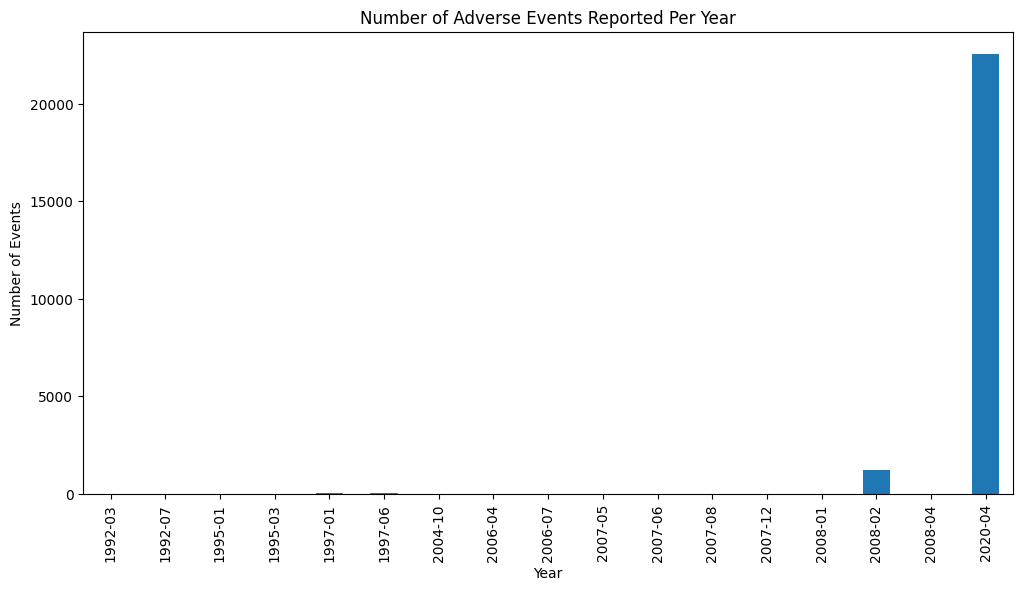

In [285]:
# Plotting Yearly Trend

events_per_year = df_final['year_month_received'].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
events_per_year.plot(kind='bar')
plt.title('Number of Adverse Events Reported Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.show()

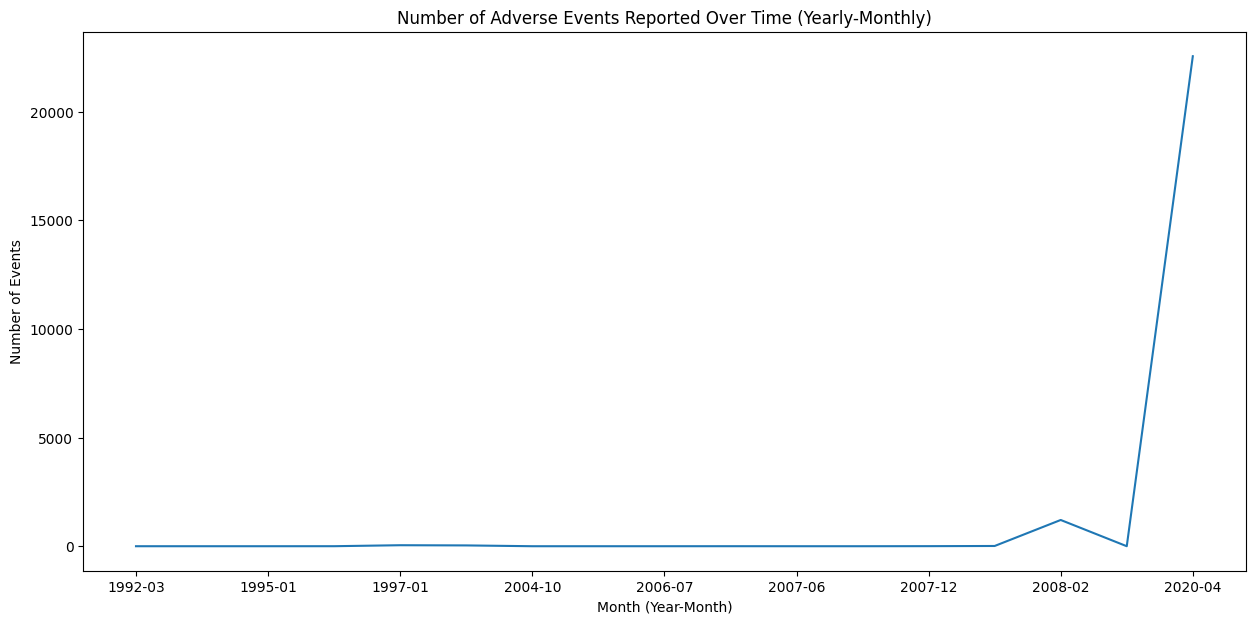

In [286]:
# Plotting Monthly Trend

events_per_month = df_final['year_month_received'].value_counts().sort_index()

plt.figure(figsize=(15,7))
events_per_month.plot()
plt.title('Number of Adverse Events Reported Over Time (Yearly-Monthly)')
plt.xlabel('Month (Year-Month)')
plt.ylabel('Number of Events')
plt.show()

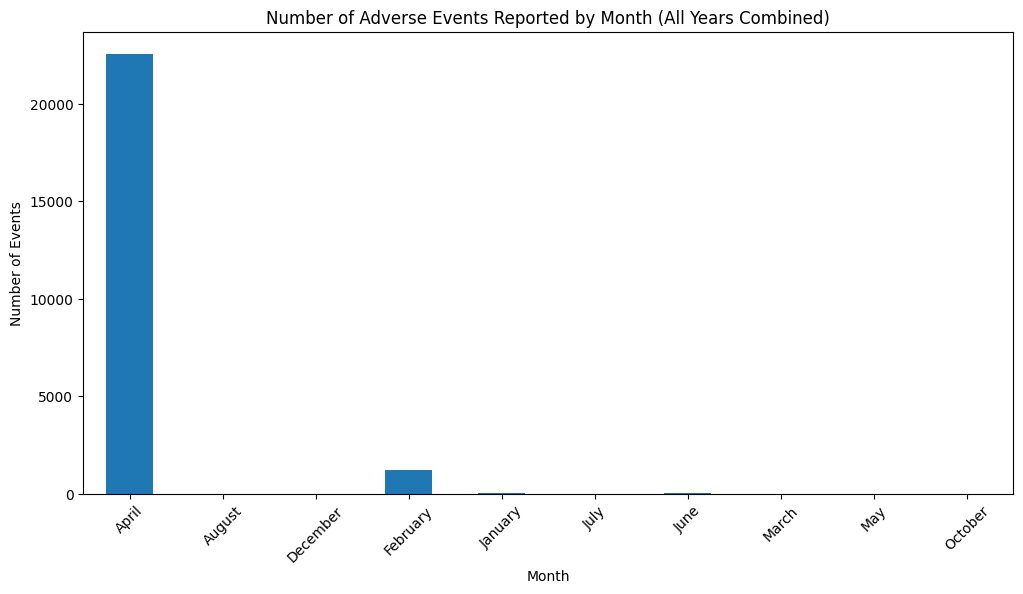

In [287]:
# Month-Only Analysis

df_final['month_only'] = df_final['date_received'].dt.month_name()  # Extract month name
# Grouping Events by Month Across All Years
events_per_month = df_final['month_only'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
events_per_month.plot(kind='bar')
plt.title('Number of Adverse Events Reported by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_final['year_received'] = pd.to_datetime(df_final['date_received']).dt.year
df_final['month_received'] = pd.to_datetime(df_final['date_received']).dt.to_period('M')

# Yearly trend
events_per_year = df_final['year_received'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
events_per_year.plot(kind='bar', color='skyblue')
plt.title('Number of Adverse Events Reported Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

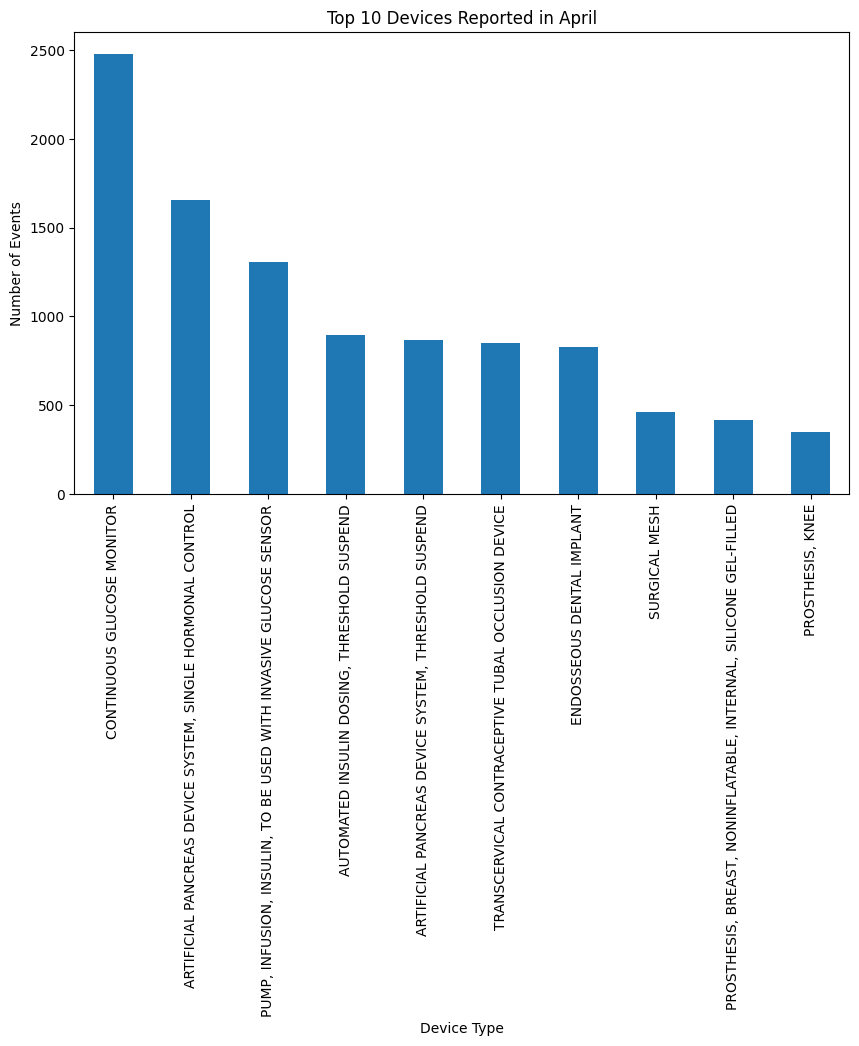

In [289]:
#  devices or manufacturers in April

april_devices = df_final[df_final['month_only'] == 'April']['device.generic_name'].value_counts().head(10)
april_devices.plot(kind='bar', figsize=(10, 6), title='Top 10 Devices Reported in April')
plt.xlabel('Device Type')
plt.ylabel('Number of Events')
plt.show()

In [290]:
# Identify Top Device Types
top_device_types = df_final['device.generic_name'].value_counts().head(10)
print("Top 10 Device Types:")
print(top_device_types)

Top 10 Device Types:
device.generic_name
CONTINUOUS GLUCOSE MONITOR                                          2641
ARTIFICIAL PANCREAS DEVICE SYSTEM, SINGLE HORMONAL CONTROL          1655
PUMP, INFUSION, INSULIN, TO BE USED WITH INVASIVE GLUCOSE SENSOR    1305
AUTOMATED INSULIN DOSING, THRESHOLD SUSPEND                          895
ARTIFICIAL PANCREAS DEVICE SYSTEM, THRESHOLD SUSPEND                 868
TRANSCERVICAL CONTRACEPTIVE TUBAL OCCLUSION DEVICE                   850
ENDOSSEOUS DENTAL IMPLANT                                            841
SURGICAL MESH                                                        461
PROSTHESIS, BREAST, NONINFLATABLE, INTERNAL, SILICONE GEL-FILLED     418
PROSTHESIS, KNEE                                                     352
Name: count, dtype: int64


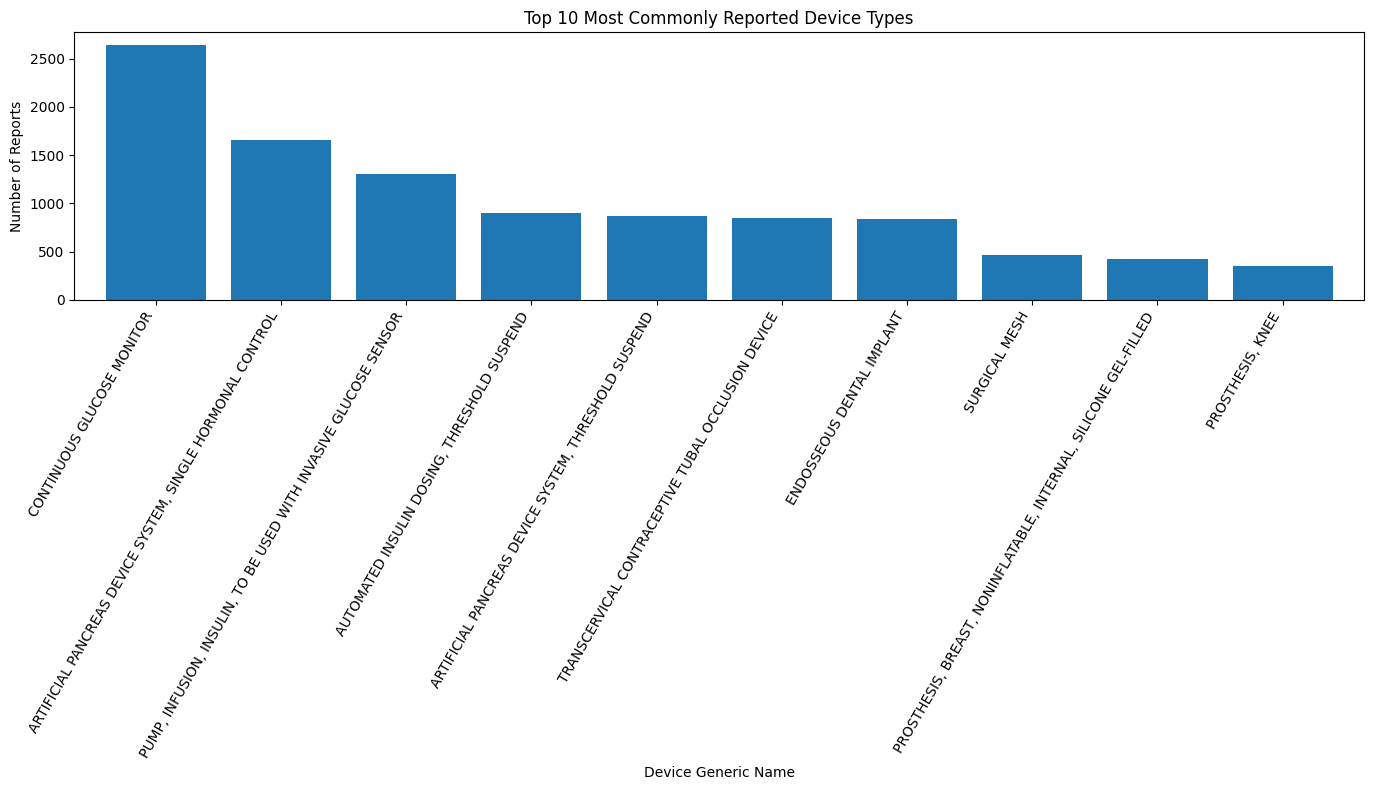

In [291]:
# MOST REPORTED DEVICES
plt.figure(figsize=(14,8))
top_device_types.plot(kind='bar', width=0.8)
plt.title('Top 10 Most Commonly Reported Device Types')
plt.xlabel('Device Generic Name')
plt.ylabel('Number of Reports')
plt.xticks(rotation=60, ha='right')  # Rotate labels at 60° and align them to the right
plt.tight_layout()  # Adjust layout to fit everything
plt.show()

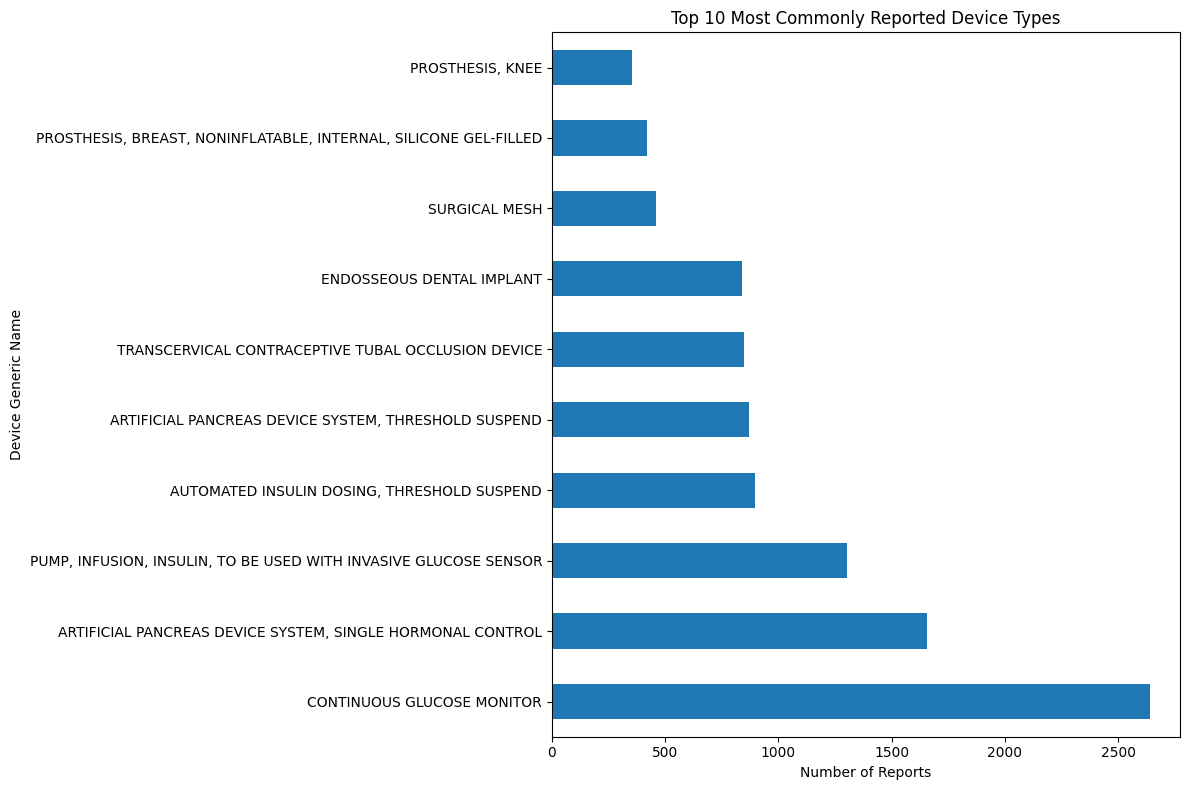

In [292]:
plt.figure(figsize=(12, 8))
top_device_types.plot(kind='barh')  # Horizontal bar chart
plt.title('Top 10 Most Commonly Reported Device Types')
plt.xlabel('Number of Reports')
plt.ylabel('Device Generic Name')
plt.tight_layout()
plt.show()

In [293]:
# Identifying Top Associated Problems

# If 'product_problems' is a string of problems separated by commas, split them
df_final['product_problems_list'] = df_final['product_problems'].str.split(', ')

# Explode the list to count each problem separately
exploded_problems = df_final.explode('product_problems_list')

top_problems = exploded_problems['product_problems_list'].value_counts().head(10)
print("Top 10 Reported Product Problems:")
print(top_problems)

Top 10 Reported Product Problems:
product_problems_list
Adverse Event Without Identified Device or Use Problem    4438
Patient Device Interaction Problem                        1729
Insufficient Information                                  1049
Wireless Communication Problem                            1037
Mechanical Problem                                         650
Failure to Osseointegrate                                  627
Break                                                      620
Fracture                                                   559
Defective Device                                           540
Power Problem                                              461
Name: count, dtype: int64


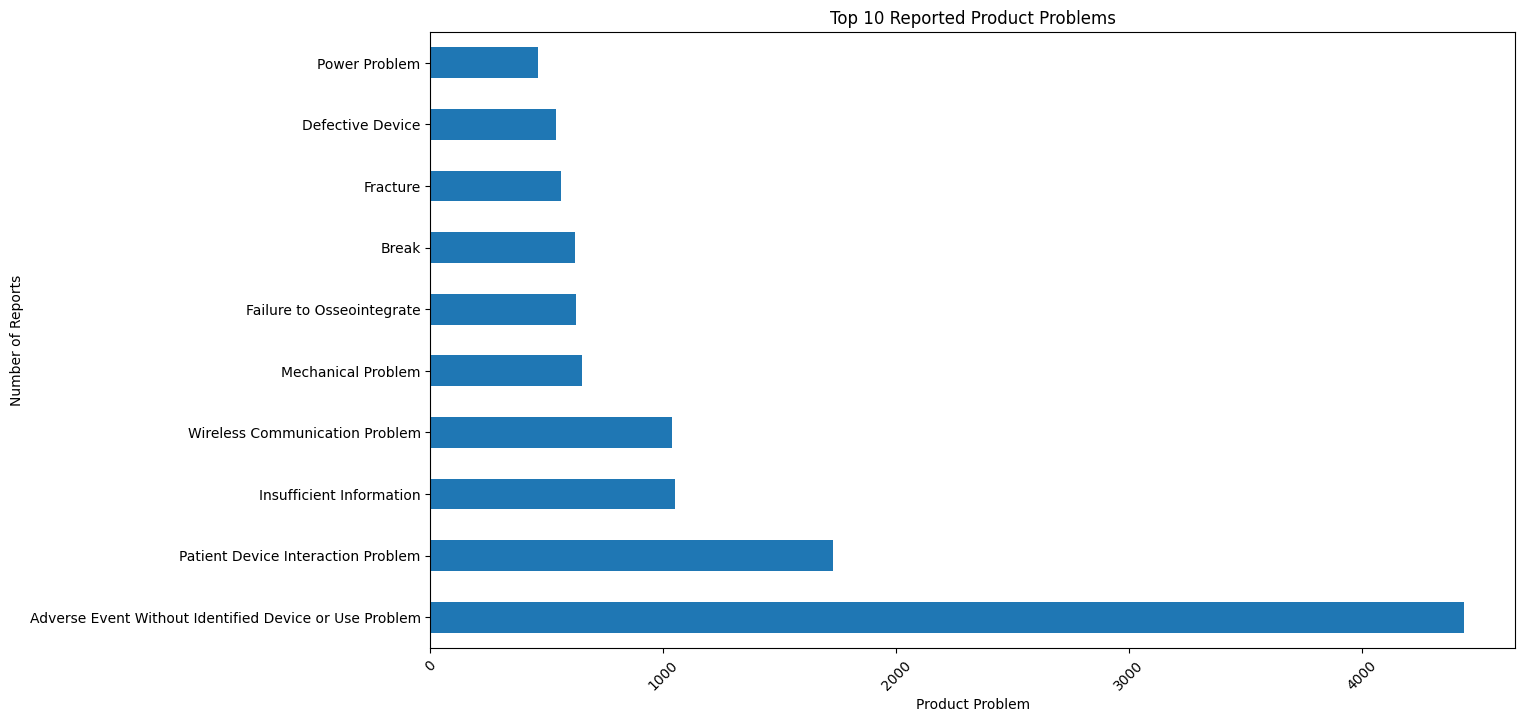

In [294]:
# MOST REPORTED PROBLEMS

plt.figure(figsize=(14,8))
top_problems.plot(kind='barh')
plt.title('Top 10 Reported Product Problems')
plt.xlabel('Product Problem')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45)
plt.show()

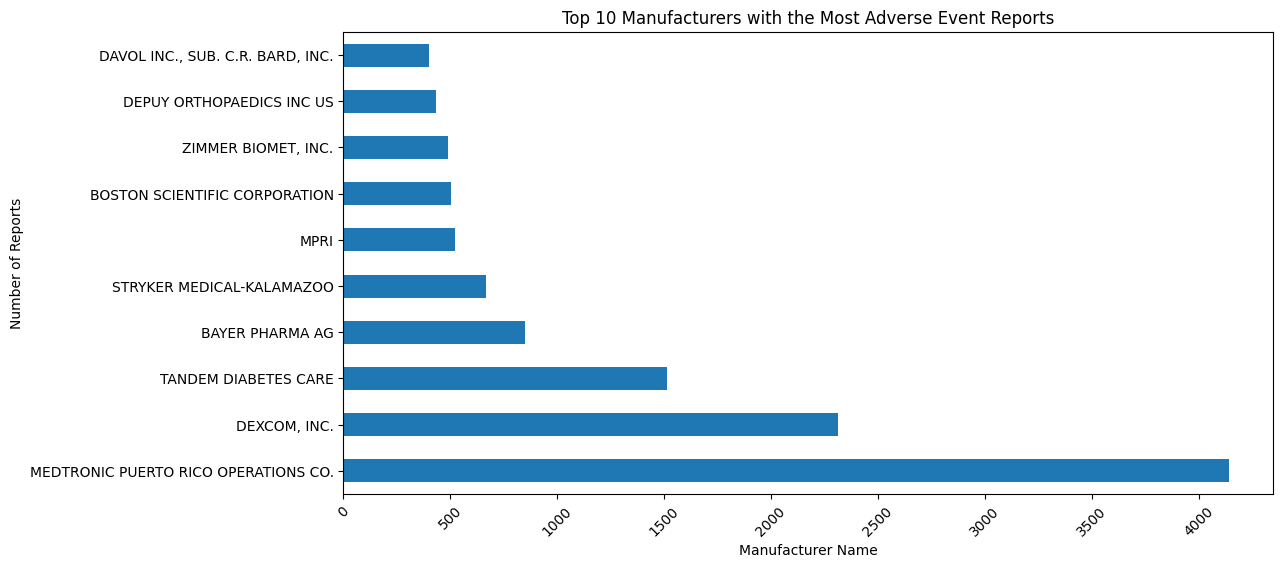

In [295]:
plt.figure(figsize=(12,6))
top_manufacturers.plot(kind='barh')
plt.title('Top 10 Manufacturers with the Most Adverse Event Reports')
plt.xlabel('Manufacturer Name')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45)
plt.show()

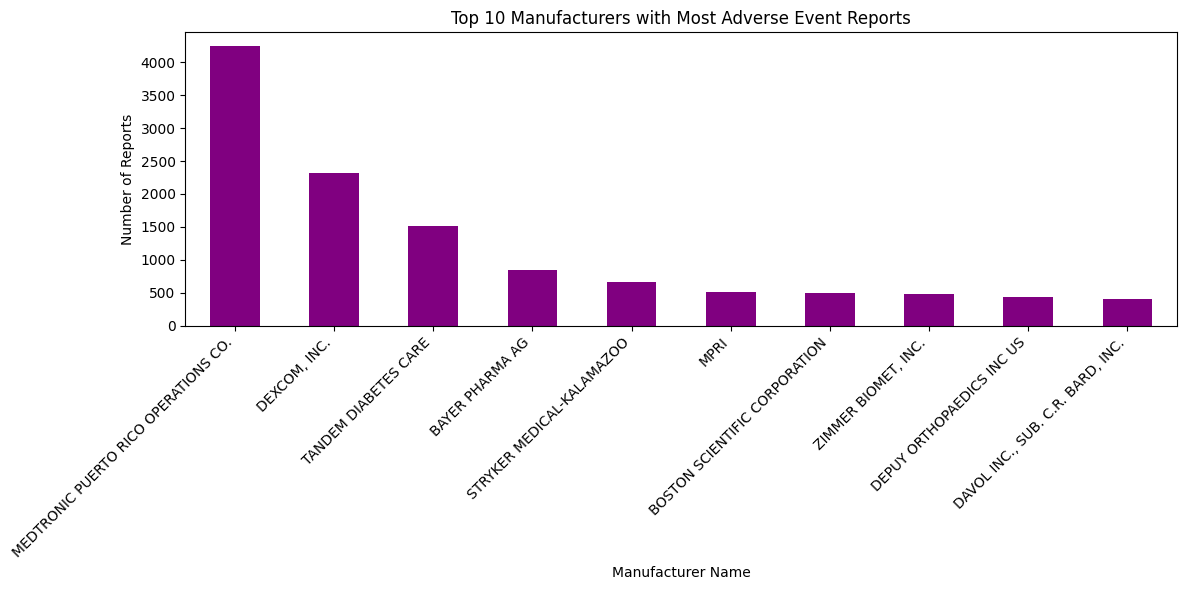

In [296]:
# Top 10 manufacturers
top_manufacturers = df_final['device.manufacturer_d_name'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_manufacturers.plot(kind='bar', color='purple')
plt.title('Top 10 Manufacturers with Most Adverse Event Reports')
plt.xlabel('Manufacturer Name')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [301]:
# Analyze Event Types
event_types_counts = df_final['event_type'].value_counts()
print("Event Types Counts:")
print(event_types_counts)

Event Types Counts:
event_type
malfunction           15591
injury                 8046
death                   207
other                    26
no answer provided        7
Name: count, dtype: int64


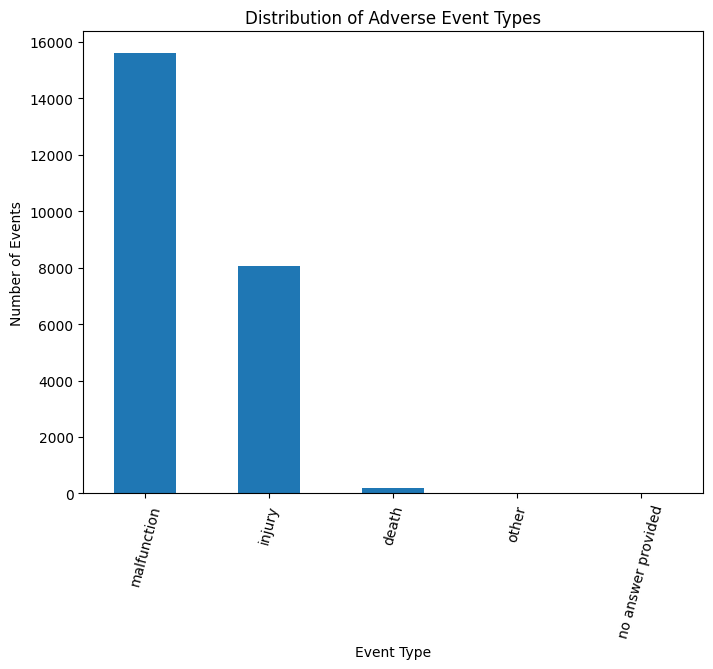

In [303]:
plt.figure(figsize=(8,6))
event_types_counts.plot(kind='bar')
plt.title('Distribution of Adverse Event Types')
plt.xlabel('Event Type')
plt.ylabel('Number of Events')
plt.xticks(rotation=75)
plt.show()

Event Severity Counts:
event_severity
Low        15591
Medium      8046
High         207
Unknown        7
Name: count, dtype: int64


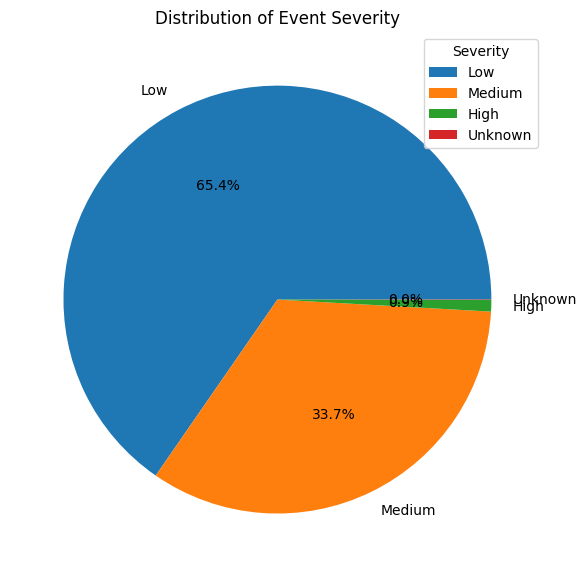

In [298]:
# Assessing Severity

# Creating a severity mapping
severity_mapping = {
    'death': 'High',
    'injury': 'Medium',
    'malfunction': 'Low',
    'no answer provided': 'Unknown',
    'invalid data': 'Unknown'
}

df_final['event_severity'] = df_final['event_type'].map(severity_mapping)

# Analyzing severity distribution
severity_counts = df_final['event_severity'].value_counts()
print("Event Severity Counts:")
print(severity_counts)

# Plotting
plt.figure(figsize=(6,6))
severity_counts.plot(kind='pie', autopct='%1.1f%%', legend=True)
plt.title('Distribution of Event Severity')
plt.ylabel('')
plt.legend(title='Severity', loc='upper right')  # Customize the legend location
plt.tight_layout()
plt.show()

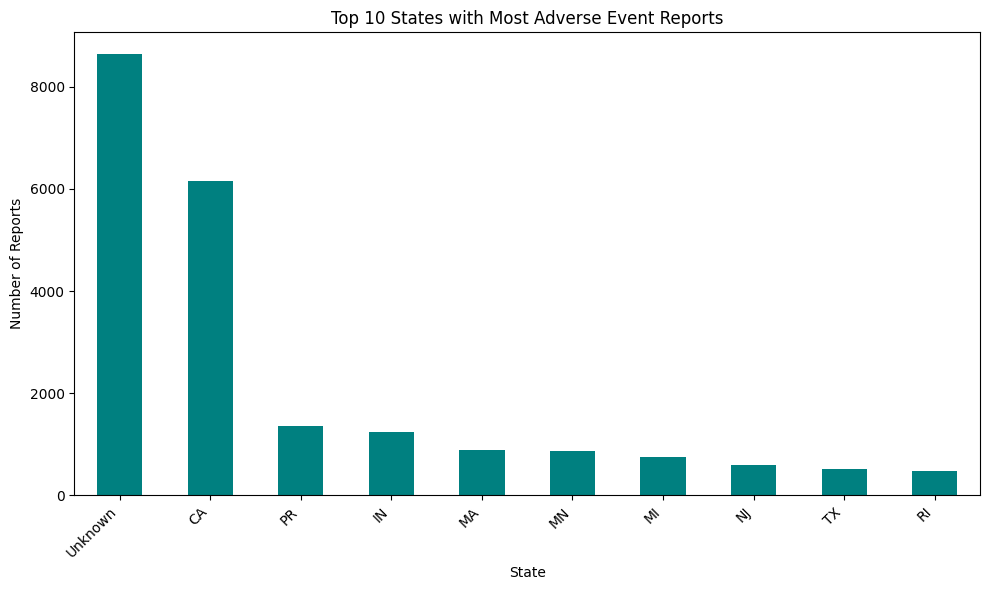

In [304]:
# Reports by state
state_counts = df_final['device.manufacturer_d_state'].value_counts().head(10)
plt.figure(figsize=(10, 6))
state_counts.plot(kind='bar', color='teal')
plt.title('Top 10 States with Most Adverse Event Reports')
plt.xlabel('State')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

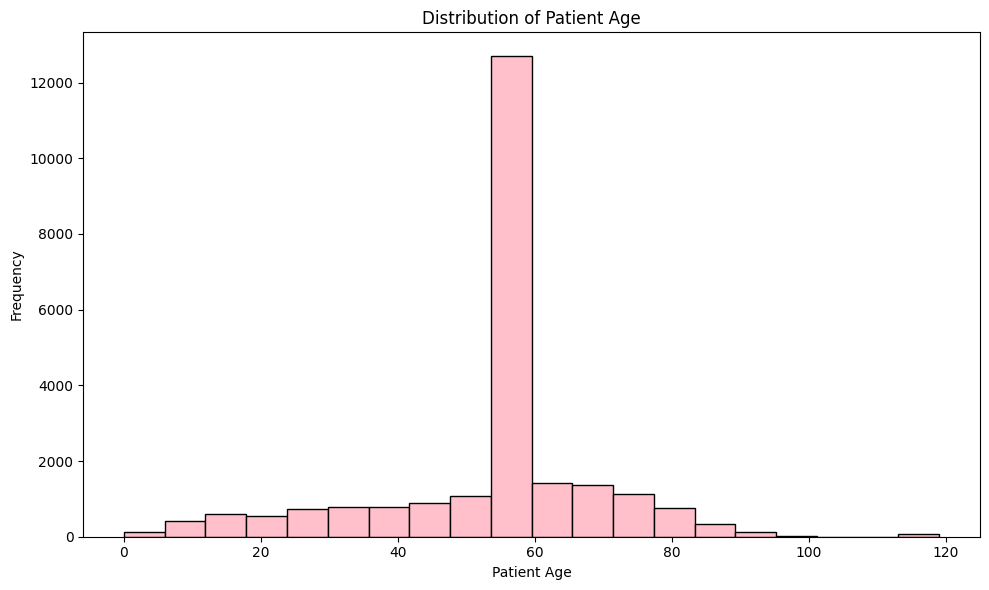

In [305]:
# Patient age distribution
plt.figure(figsize=(10, 6))
df_final['patient.patient_age'].plot(kind='hist', bins=20, color='pink', edgecolor='black')
plt.title('Distribution of Patient Age')
plt.xlabel('Patient Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()